# Duplicate-Aware Evaluation of API N-Gram Malware Classification

Eight-category classification on Mal-API-2019. This is the recorded experiment notebook, including saved outputs. See the repository README before running. The notebook contains several Colab sessions and hard-coded resume paths; do not use Run all without adapting those paths.

Grouped five-fold evaluation, feature and weighting comparisons, and ordinary versus grouped Random Forest evaluation. No binary detection or metamorphic-robustness claim.


## A. Original weighted 1–3 gram experiment (original code cells 0–24)

Code and saved outputs below are preserved from the submitted experiment.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path

drive_folder = Path("/content/drive/MyDrive")

zip_files = sorted(
    drive_folder.rglob("mal-api-2019*.zip")
)

print("Matching dataset ZIP files:", len(zip_files))

for number, file_path in enumerate(zip_files, start=1):
    size_mb = file_path.stat().st_size / (1024 * 1024)

    print(f"\nFile {number}")
    print("Path:", file_path)
    print(f"Size: {size_mb:.2f} MB")

if len(zip_files) == 0:
    raise FileNotFoundError(
        "Upload the dataset ZIP to your Google Drive, "
        "wait for the upload to finish, and run this cell again."
    )

Matching dataset ZIP files: 1

File 1
Path: /content/drive/MyDrive/mal-api-2019-20260919T173115Z-1-001.zip
Size: 4.70 MB


In [ ]:
import shutil
import zipfile

# If Step 3 lists several files, select the correct file number here.
selected_file_number = 1

if not 1 <= selected_file_number <= len(zip_files):
    raise ValueError(
        "The selected file number does not exist. "
        "Check the list printed in Step 3."
    )

source_zip = zip_files[selected_file_number - 1]

local_folder = Path("/content/malapi_work")
local_folder.mkdir(parents=True, exist_ok=True)

local_zip = local_folder / "dataset.zip"

print("Copying:", source_zip.name)

shutil.copy2(source_zip, local_zip)

if not zipfile.is_zipfile(local_zip):
    raise ValueError("The selected file is not a valid ZIP archive.")

with zipfile.ZipFile(local_zip) as archive:
    print("\nFiles inside the ZIP:")

    for member in archive.infolist():
        if not member.is_dir():
            size_mb = member.file_size / (1024 * 1024)
            print(f"{member.filename} — {size_mb:.2f} MB")

print("\nZIP is ready.")

Copying: mal-api-2019-20260919T173115Z-1-001.zip

Files inside the ZIP:
mal-api-2019/mal-api-2019/labels.csv — 0.06 MB
mal-api-2019/1000_calls.csv — 496.00 MB

ZIP is ready.


In [ ]:
import csv
import io
import hashlib

import numpy as np
import pandas as pd

with zipfile.ZipFile(local_zip) as archive:

    calls_files = [
        name
        for name in archive.namelist()
        if Path(name).name == "1000_calls.csv"
    ]

    labels_files = [
        name
        for name in archive.namelist()
        if Path(name).name == "labels.csv"
    ]

    if len(calls_files) != 1:
        raise ValueError(
            "Expected exactly one 1000_calls.csv inside the ZIP. "
            f"Found: {calls_files}"
        )

    if len(labels_files) != 1:
        raise ValueError(
            "Expected exactly one labels.csv inside the ZIP. "
            f"Found: {labels_files}"
        )

    # This label file has no header.
    with archive.open(labels_files[0]) as label_file:
        label_table = pd.read_csv(
            label_file,
            header=None,
            names=["label"],
            dtype=str,
            keep_default_na=False,
            skip_blank_lines=False
        )

    labels = label_table["label"].str.strip().tolist()

    if any(label == "" for label in labels):
        raise ValueError(
            "An empty label was found. Stop and inspect the file."
        )

    sequences = []
    sequence_lengths = []
    sequence_hashes = []

    with archive.open(calls_files[0]) as calls_file:

        text_file = io.TextIOWrapper(
            calls_file,
            encoding="utf-8-sig",
            newline=""
        )

        reader = csv.reader(text_file)

        for row_number, row in enumerate(reader, start=1):

            if not row:
                raise ValueError(
                    f"Empty sequence row found at row {row_number}. "
                    "Rows must not be silently skipped."
                )

            calls = [value.strip() for value in row]

            if any(call == "" for call in calls):
                raise ValueError(
                    f"An empty API field was found in row {row_number}. "
                    "Inspect the format before continuing."
                )

            if not all(call.isdigit() for call in calls):
                raise ValueError(
                    f"Unexpected non-numeric API value in row {row_number}."
                )

            # Every field is an API call. Do not remove the first field.
            sequence = " ".join(calls)

            sequences.append(sequence)
            sequence_lengths.append(len(calls))

            sequence_hashes.append(
                hashlib.sha256(
                    sequence.encode("utf-8")
                ).hexdigest()
            )

            if row_number % 1000 == 0:
                print(f"Loaded {row_number:,} sequences")

if len(sequences) != len(labels):
    raise ValueError(
        "Sequence and label counts do not match. "
        f"Sequences: {len(sequences)}, labels: {len(labels)}"
    )

if len(sequences) != 7107:
    raise ValueError(
        f"Expected 7,107 samples in this dataset, found {len(sequences)}."
    )

data = pd.DataFrame({
    "sample_id": np.arange(len(sequences)),
    "api_sequence": sequences,
    "label": labels,
    "api_call_count": sequence_lengths,
    "sequence_group": sequence_hashes
})

expected_counts = {
    "Trojan": 1001,
    "Backdoor": 1001,
    "Downloader": 1001,
    "Worms": 1001,
    "Virus": 1001,
    "Spyware": 832,
    "Dropper": 891,
    "Adware": 379
}

actual_counts = data["label"].value_counts().to_dict()

if actual_counts != expected_counts:
    raise ValueError(
        "The class counts differ from the verified uploaded dataset. "
        f"Actual counts: {actual_counts}"
    )

print("\nDATA LOADED SUCCESSFULLY")
print("Sequences:", len(sequences))
print("Labels:", len(labels))
print("Paired samples:", len(data))
print("Classes:", data["label"].nunique())

print("\nClass counts:")
display(
    data["label"]
    .value_counts()
    .rename_axis("Malware type")
    .reset_index(name="Samples")
)

print("\nFirst five sequence-label pairs:")
display(
    data[
        ["sample_id", "api_sequence", "label", "api_call_count"]
    ].head()
)

Loaded 1,000 sequences
Loaded 2,000 sequences
Loaded 3,000 sequences
Loaded 4,000 sequences
Loaded 5,000 sequences
Loaded 6,000 sequences
Loaded 7,000 sequences

DATA LOADED SUCCESSFULLY
Sequences: 7107
Labels: 7107
Paired samples: 7107
Classes: 8

Class counts:


,Malware type,Samples
0,Trojan,1001
1,Backdoor,1001
2,Downloader,1001
3,Worms,1001
4,Virus,1001
5,Dropper,891
6,Spyware,832
7,Adware,379



First five sequence-label pairs:


,sample_id,api_sequence,label,api_call_count
0,0,292 291 292 291 291 291 291 291 291 291 291 29...,Trojan,287
1,1,278 192 199 192 290 291 291 291 291 290 291 29...,Trojan,263
2,2,290 291 51 34 232 238 220 221 220 69 69 66 80 ...,Backdoor,49
3,3,292 291 292 291 291 291 291 291 291 291 291 29...,Backdoor,1034
4,4,292 291 291 291 291 291 291 291 291 291 291 29...,Trojan,179


In [ ]:
group_summary = (
    data.groupby("sequence_group")
    .agg(
        sample_count=("sample_id", "size"),
        label_count=("label", "nunique")
    )
)

duplicate_groups = group_summary[
    group_summary["sample_count"] > 1
]

conflicting_groups = group_summary[
    group_summary["label_count"] > 1
]

print("Total samples:", len(data))
print("Unique sequences:", len(group_summary))

print(
    "Additional copies of repeated sequences:",
    data["sequence_group"].duplicated().sum()
)

print(
    "Groups containing repeated sequences:",
    len(duplicate_groups)
)

print(
    "Identical-sequence groups with conflicting labels:",
    len(conflicting_groups)
)

print("\nSequence length summary:")
display(data["api_call_count"].describe())

print(
    "\nSequences longer than 1,000 calls:",
    int((data["api_call_count"] > 1000).sum())
)

print("\nNo samples have been deleted or relabelled.")

Total samples: 7107
Unique sequences: 6518
Additional copies of repeated sequences: 589
Groups containing repeated sequences: 290
Identical-sequence groups with conflicting labels: 33

Sequence length summary:


,api_call_count
count,7.107000e+03
mean,1.964727e+04
std,1.090134e+05
min,1.000000e+01
25%,2.240000e+02
50%,6.330000e+02
75%,1.862000e+03
max,1.764421e+06



Sequences longer than 1,000 calls: 2558

No samples have been deleted or relabelled.


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

token_check = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 2)
)

example_sequence = "292 7 51"

generated_features = token_check.build_analyzer()(
    example_sequence
)

print("Example sequence:")
print(example_sequence)

print("\nGenerated features:")
print(generated_features)

expected_features = [
    "292",
    "7",
    "51",
    "292 7",
    "7 51"
]

assert generated_features == expected_features

print("\nPASS: single-digit IDs and local call order are preserved.")

Example sequence:
292 7 51

Generated features:
['292', '7', '51', '292 7', '7 51']

PASS: single-digit IDs and local call order are preserved.


In [ ]:
from sklearn.model_selection import StratifiedGroupKFold

required_columns = {
    "sample_id",
    "api_sequence",
    "label",
    "sequence_group"
}

assert required_columns.issubset(data.columns)
assert len(data) == 7107
assert data["label"].nunique() == 8

splitter = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

folds = list(
    splitter.split(
        X=data["api_sequence"],
        y=data["label"],
        groups=data["sequence_group"]
    )
)

fold_assignment = np.full(len(data), -1, dtype=int)
fold_checks = []
all_classes = set(data["label"])

for fold_number, (train_indices, test_indices) in enumerate(
    folds,
    start=1
):
    train_groups = set(
        data.iloc[train_indices]["sequence_group"]
    )

    test_groups = set(
        data.iloc[test_indices]["sequence_group"]
    )

    overlap = train_groups.intersection(test_groups)

    assert len(overlap) == 0, "Duplicate overlap detected!"

    assert set(
        data.iloc[train_indices]["label"]
    ) == all_classes, "A training fold is missing a class."

    assert set(
        data.iloc[test_indices]["label"]
    ) == all_classes, "A test fold is missing a class."

    assert np.all(fold_assignment[test_indices] == -1)

    fold_assignment[test_indices] = fold_number

    fold_checks.append({
        "Fold": fold_number,
        "Training samples": len(train_indices),
        "Test samples": len(test_indices),
        "Shared sequence groups": len(overlap)
    })

assert np.all(fold_assignment > 0)

display(pd.DataFrame(fold_checks))

print("\nPASS: no identical sequences cross any fold boundary.")
print("PASS: all eight classes appear in every training and test fold.")
print("PASS: every sample is held out exactly once.")

,Fold,Training samples,Test samples,Shared sequence groups
0,1,5688,1419,0
1,2,5660,1447,0
2,3,5709,1398,0
3,4,5678,1429,0
4,5,5693,1414,0



PASS: no identical sequences cross any fold boundary.
PASS: all eight classes appear in every training and test fold.
PASS: every sample is held out exactly once.


In [ ]:
from pathlib import Path
from datetime import datetime
import json
import sklearn

run_name = datetime.now().strftime("%Y%m%d_%H%M%S")

results_folder = (
    Path("/content/drive/MyDrive")
    / "MalAPI_Corrected_Results"
    / run_name
)

results_folder.mkdir(parents=True, exist_ok=True)

fold_manifest = data[
    ["sample_id", "label", "sequence_group", "api_call_count"]
].copy()

fold_manifest["test_fold"] = fold_assignment

fold_manifest.to_csv(
    results_folder / "fold_assignments.csv",
    index=False
)

settings = {
    "samples": len(data),
    "classes": sorted(data["label"].unique().tolist()),
    "split_method": "StratifiedGroupKFold",
    "number_of_folds": 5,
    "random_state": 42,
    "grouping": "SHA256 of full API sequence",
    "sequence_length_limit": None,
    "conflicting_labels": "Retained as supplied",
    "sklearn_version": sklearn.__version__
}

with open(
    results_folder / "experiment_settings.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(settings, file, indent=2)

print("Saved experiment settings and fold assignments.")
print("Results folder:", results_folder)

Saved experiment settings and fold assignments.
Results folder: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045


In [ ]:
train_indices, test_indices = folds[0]

train_sequences = data.iloc[train_indices]["api_sequence"]
test_sequences = data.iloc[test_indices]["api_sequence"]

train_labels = data.iloc[train_indices]["label"]
test_labels = data.iloc[test_indices]["label"]

class_names = sorted(data["label"].unique())

distribution = pd.DataFrame({
    "Training": train_labels.value_counts(),
    "Testing": test_labels.value_counts()
}).reindex(class_names).fillna(0).astype(int)

print("FIRST FOLD")
print("Training samples:", len(train_sequences))
print("Testing samples:", len(test_sequences))

display(distribution)

FIRST FOLD
Training samples: 5688
Testing samples: 1419


,Training,Testing
label,,
Adware,309,70
Backdoor,835,166
Downloader,762,239
Dropper,704,187
Spyware,681,151
Trojan,819,182
Virus,780,221
Worms,798,203


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from time import perf_counter

vectorizer = TfidfVectorizer(
    tokenizer=str.split,
    token_pattern=None,
    lowercase=False,
    ngram_range=(1, 3),
    min_df=2,
    max_features=50000,
    dtype=np.float32
)

start_time = perf_counter()

print("Learning TF-IDF features from training sequences...", flush=True)

train_features = vectorizer.fit_transform(train_sequences)

print("Transforming test sequences...", flush=True)

test_features = vectorizer.transform(test_sequences)

feature_time = perf_counter() - start_time

assert train_features.shape[0] == len(train_labels)
assert test_features.shape[0] == len(test_labels)
assert train_features.shape[1] == test_features.shape[1]

print("\nFEATURES READY")
print("Training matrix:", train_features.shape)
print("Testing matrix:", test_features.shape)
print(f"Feature preparation time: {feature_time:.1f} seconds")

empty_train = int(
    np.sum(train_features.getnnz(axis=1) == 0)
)

empty_test = int(
    np.sum(test_features.getnnz(axis=1) == 0)
)

print("Training rows with no retained features:", empty_train)
print("Testing rows with no retained features:", empty_test)

Learning TF-IDF features from training sequences...
Transforming test sequences...

FEATURES READY
Training matrix: (5688, 38648)
Testing matrix: (1419, 38648)
Feature preparation time: 208.4 seconds
Training rows with no retained features: 0
Testing rows with no retained features: 0


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

print("Training Random Forest...", flush=True)

start_time = perf_counter()

rf_model.fit(
    train_features,
    train_labels
)

rf_training_time = perf_counter() - start_time

print("\nTRAINING COMPLETED")
print(f"Training time: {rf_training_time:.1f} seconds")

Training Random Forest...

TRAINING COMPLETED
Training time: 113.6 seconds


In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

start_time = perf_counter()

rf_predictions = rf_model.predict(test_features)

rf_prediction_time = perf_counter() - start_time

most_common_class = train_labels.value_counts().idxmax()

baseline_predictions = np.repeat(
    most_common_class,
    len(test_labels)
)

def calculate_metrics(model_name, predictions):
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(
            test_labels, predictions
        ),
        "Macro Precision": precision_score(
            test_labels,
            predictions,
            labels=class_names,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            test_labels,
            predictions,
            labels=class_names,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            test_labels,
            predictions,
            labels=class_names,
            average="macro",
            zero_division=0
        )
    }

first_fold_results = pd.DataFrame([
    calculate_metrics(
        "Most-common-class baseline",
        baseline_predictions
    ),
    calculate_metrics(
        "Random Forest",
        rf_predictions
    )
])

print("FIRST-FOLD RESULTS")
display(first_fold_results.round(4))

print("\nRANDOM FOREST CLASSIFICATION REPORT")
print(
    classification_report(
        test_labels,
        rf_predictions,
        labels=class_names,
        digits=4,
        zero_division=0
    )
)

print(f"Training time: {rf_training_time:.1f} seconds")
print(f"Prediction time: {rf_prediction_time:.3f} seconds")

first_fold_results.to_csv(
    results_folder / "fold1_random_forest_metrics.csv",
    index=False
)

prediction_table = pd.DataFrame({
    "sample_id": data.iloc[test_indices]["sample_id"].to_numpy(),
    "true_label": test_labels.to_numpy(),
    "predicted_label": rf_predictions
})

prediction_table.to_csv(
    results_folder / "fold1_random_forest_predictions.csv",
    index=False
)

report = classification_report(
    test_labels,
    rf_predictions,
    labels=class_names,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(report).transpose().to_csv(
    results_folder / "fold1_random_forest_class_report.csv"
)

pd.DataFrame([{
    "Feature preparation seconds": feature_time,
    "Training seconds": rf_training_time,
    "Prediction seconds": rf_prediction_time
}]).to_csv(
    results_folder / "fold1_random_forest_timing.csv",
    index=False
)

print("\nResults saved to:", results_folder)

FIRST-FOLD RESULTS


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Most-common-class baseline,0.1170,0.0146,0.1250,0.0262
1,Random Forest,0.6568,0.6658,0.6515,0.6556



RANDOM FOREST CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Adware     0.8596    0.7000    0.7717        70
    Backdoor     0.6519    0.7108    0.6801       166
  Downloader     0.8600    0.7197    0.7836       239
     Dropper     0.5631    0.6684    0.6112       187
     Spyware     0.4938    0.5298    0.5112       151
      Trojan     0.4824    0.4505    0.4659       182
       Virus     0.7759    0.8462    0.8095       221
       Worms     0.6398    0.5862    0.6118       203

    accuracy                         0.6568      1419
   macro avg     0.6658    0.6515    0.6556      1419
weighted avg     0.6645    0.6568    0.6579      1419

Training time: 113.6 seconds
Prediction time: 0.572 seconds

Results saved to: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045


In [ ]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "xgboost"
    ])

import xgboost
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight

print("XGBoost version:", xgboost.__version__)
print("Ready.")

XGBoost version: 3.4.1
Ready.


In [ ]:
label_encoder = LabelEncoder()

train_labels_encoded = label_encoder.fit_transform(
    train_labels
)

assert list(label_encoder.classes_) == class_names

training_weights = compute_sample_weight(
    class_weight="balanced",
    y=train_labels_encoded
)

print("Class mapping:")

for number, name in enumerate(label_encoder.classes_):
    print(f"{number}: {name}")

print("\nTraining samples:", len(train_labels_encoded))
print("Training weights:", len(training_weights))

assert len(train_labels_encoded) == train_features.shape[0]
assert len(training_weights) == train_features.shape[0]

print("\nPASS: labels and weights match the training data.")

Class mapping:
0: Adware
1: Backdoor
2: Downloader
3: Dropper
4: Spyware
5: Trojan
6: Virus
7: Worms

Training samples: 5688
Training weights: 5688

PASS: labels and weights match the training data.


In [ ]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(class_names),
    eval_metric="mlogloss",
    random_state=42,
    n_jobs=-1,
    tree_method="hist"
)

print("Training XGBoost on Fold 1...", flush=True)
print("Please wait until TRAINING COMPLETED appears.", flush=True)

start_time = perf_counter()

xgb_model.fit(
    train_features,
    train_labels_encoded,
    sample_weight=training_weights
)

xgb_training_time = perf_counter() - start_time

print("\nTRAINING COMPLETED")
print(f"Training time: {xgb_training_time:.1f} seconds")

Training XGBoost on Fold 1...
Please wait until TRAINING COMPLETED appears.

TRAINING COMPLETED
Training time: 1756.5 seconds


In [ ]:
start_time = perf_counter()

xgb_predictions_encoded = xgb_model.predict(
    test_features
).astype(int)

xgb_prediction_time = perf_counter() - start_time

xgb_predictions = label_encoder.inverse_transform(
    xgb_predictions_encoded
)

comparison_results = pd.DataFrame([
    calculate_metrics(
        "Most-common-class baseline",
        baseline_predictions
    ),
    calculate_metrics(
        "Random Forest",
        rf_predictions
    ),
    calculate_metrics(
        "XGBoost",
        xgb_predictions
    )
])

print("FOLD 1 — MODEL COMPARISON")
display(comparison_results.round(4))

print("\nXGBOOST CLASSIFICATION REPORT")

print(
    classification_report(
        test_labels,
        xgb_predictions,
        labels=class_names,
        digits=4,
        zero_division=0
    )
)

print(f"Training time: {xgb_training_time:.1f} seconds")
print(f"Prediction time: {xgb_prediction_time:.3f} seconds")

comparison_results.to_csv(
    results_folder / "fold1_rf_xgb_comparison.csv",
    index=False
)

pd.DataFrame({
    "sample_id": data.iloc[test_indices]["sample_id"].to_numpy(),
    "true_label": test_labels.to_numpy(),
    "rf_prediction": rf_predictions,
    "xgb_prediction": xgb_predictions
}).to_csv(
    results_folder / "fold1_rf_xgb_predictions.csv",
    index=False
)

xgb_report = classification_report(
    test_labels,
    xgb_predictions,
    labels=class_names,
    output_dict=True,
    zero_division=0
)

pd.DataFrame(xgb_report).transpose().to_csv(
    results_folder / "fold1_xgb_class_report.csv"
)

pd.DataFrame([{
    "Model": "XGBoost",
    "Training seconds": xgb_training_time,
    "Prediction seconds": xgb_prediction_time
}]).to_csv(
    results_folder / "fold1_xgb_timing.csv",
    index=False
)

print("\nResults saved to:", results_folder)

FOLD 1 — MODEL COMPARISON


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Most-common-class baseline,0.1170,0.0146,0.1250,0.0262
1,Random Forest,0.6568,0.6658,0.6515,0.6556
2,XGBoost,0.6892,0.7019,0.6777,0.6862



XGBOOST CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Adware     0.9000    0.6429    0.7500        70
    Backdoor     0.6798    0.7289    0.7035       166
  Downloader     0.8091    0.7448    0.7756       239
     Dropper     0.5896    0.6684    0.6266       187
     Spyware     0.5210    0.5762    0.5472       151
      Trojan     0.5421    0.5659    0.5538       182
       Virus     0.8967    0.8643    0.8802       221
       Worms     0.6772    0.6305    0.6531       203

    accuracy                         0.6892      1419
   macro avg     0.7019    0.6777    0.6862      1419
weighted avg     0.6994    0.6892    0.6923      1419

Training time: 1756.5 seconds
Prediction time: 0.505 seconds

Results saved to: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045


In [ ]:
import joblib

checkpoint_path = results_folder / "fold1_rf_xgb_checkpoint.joblib"

checkpoint = {
    "vectorizer": vectorizer,
    "rf_model": rf_model,
    "xgb_model": xgb_model,
    "label_encoder": label_encoder,
    "class_names": class_names,
    "train_indices": train_indices,
    "test_indices": test_indices,
    "rf_predictions": rf_predictions,
    "xgb_predictions": xgb_predictions,
    "rf_training_time": rf_training_time,
    "xgb_training_time": xgb_training_time
}

print("Saving trained models to Drive...", flush=True)

joblib.dump(
    checkpoint,
    checkpoint_path,
    compress=3
)

print("CHECKPOINT SAVED")
print(checkpoint_path)

Saving trained models to Drive...
CHECKPOINT SAVED
/content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045/fold1_rf_xgb_checkpoint.joblib


In [ ]:
from sklearn.svm import SVC

svm_model = SVC(
    kernel="linear",
    C=1.0,
    probability=True,
    class_weight="balanced",
    random_state=42,
    cache_size=512
)

print("Training linear SVM on Fold 1...", flush=True)
print("Probability estimation is enabled for soft voting.", flush=True)
print("Please wait for TRAINING COMPLETED.", flush=True)

start_time = perf_counter()

svm_model.fit(
    train_features,
    train_labels
)

svm_training_time = perf_counter() - start_time

print("\nTRAINING COMPLETED")
print(f"Training time: {svm_training_time:.1f} seconds")

start_time = perf_counter()

svm_predictions = svm_model.predict(test_features)

svm_prediction_time = perf_counter() - start_time

print("\nSVM RESULTS")

display(
    pd.DataFrame([
        calculate_metrics("SVM", svm_predictions)
    ]).round(4)
)

print(
    classification_report(
        test_labels,
        svm_predictions,
        labels=class_names,
        digits=4,
        zero_division=0
    )
)

joblib.dump(
    svm_model,
    results_folder / "fold1_svm_model.joblib",
    compress=3
)

pd.DataFrame({
    "sample_id": data.iloc[test_indices]["sample_id"].to_numpy(),
    "true_label": test_labels.to_numpy(),
    "svm_prediction": svm_predictions
}).to_csv(
    results_folder / "fold1_svm_predictions.csv",
    index=False
)

pd.DataFrame([{
    "Training seconds": svm_training_time,
    "Prediction seconds": svm_prediction_time
}]).to_csv(
    results_folder / "fold1_svm_timing.csv",
    index=False
)

print("\nSVM model and results saved.")

Training linear SVM on Fold 1...
Probability estimation is enabled for soft voting.
Please wait for TRAINING COMPLETED.

TRAINING COMPLETED
Training time: 487.5 seconds

SVM RESULTS


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,SVM,0.487,0.5196,0.4889,0.4889


              precision    recall  f1-score   support

      Adware     0.5714    0.5714    0.5714        70
    Backdoor     0.3643    0.6386    0.4639       166
  Downloader     0.8000    0.6025    0.6874       239
     Dropper     0.3918    0.3583    0.3743       187
     Spyware     0.2895    0.4371    0.3483       151
      Trojan     0.3266    0.3571    0.3412       182
       Virus     0.7895    0.6109    0.6888       221
       Worms     0.6239    0.3350    0.4359       203

    accuracy                         0.4870      1419
   macro avg     0.5196    0.4889    0.4889      1419
weighted avg     0.5421    0.4870    0.4980      1419


SVM model and results saved.


In [ ]:
print("Calculating probabilities from the trained models...", flush=True)

start_time = perf_counter()

rf_probabilities = rf_model.predict_proba(test_features)
xgb_probabilities = xgb_model.predict_proba(test_features)
svm_probabilities = svm_model.predict_proba(test_features)

# Put every model's probability columns in the same class order.
rf_positions = [
    list(rf_model.classes_).index(name)
    for name in class_names
]

svm_positions = [
    list(svm_model.classes_).index(name)
    for name in class_names
]

xgb_positions = [
    list(xgb_model.classes_).index(
        int(label_encoder.transform([name])[0])
    )
    for name in class_names
]

rf_aligned = rf_probabilities[:, rf_positions]
xgb_aligned = xgb_probabilities[:, xgb_positions]
svm_aligned = svm_probabilities[:, svm_positions]

for probabilities in [
    rf_aligned,
    xgb_aligned,
    svm_aligned
]:
    assert probabilities.shape == (
        len(test_labels),
        len(class_names)
    )

    assert np.isfinite(probabilities).all()

    assert np.allclose(
        probabilities.sum(axis=1),
        1.0,
        atol=1e-5
    )

ensemble_probabilities = (
    rf_aligned + xgb_aligned + svm_aligned
) / 3.0

ensemble_predictions = np.asarray(class_names)[
    np.argmax(ensemble_probabilities, axis=1)
]

ensemble_prediction_time = perf_counter() - start_time

final_fold1_results = pd.DataFrame([
    calculate_metrics(
        "Most-common-class baseline",
        baseline_predictions
    ),
    calculate_metrics(
        "Random Forest",
        rf_predictions
    ),
    calculate_metrics(
        "XGBoost",
        xgb_predictions
    ),
    calculate_metrics(
        "SVM",
        svm_predictions
    ),
    calculate_metrics(
        "Soft Voting Ensemble",
        ensemble_predictions
    )
])

print("\nFOLD 1 — COMPLETE COMPARISON")
display(final_fold1_results.round(4))

print("\nENSEMBLE CLASSIFICATION REPORT")

print(
    classification_report(
        test_labels,
        ensemble_predictions,
        labels=class_names,
        digits=4,
        zero_division=0
    )
)

print(
    "Ensemble prediction time, including all three models:",
    f"{ensemble_prediction_time:.3f} seconds"
)

Calculating probabilities from the trained models...

FOLD 1 — COMPLETE COMPARISON


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Most-common-class baseline,0.1170,0.0146,0.1250,0.0262
1,Random Forest,0.6568,0.6658,0.6515,0.6556
2,XGBoost,0.6892,0.7019,0.6777,0.6862
3,SVM,0.4870,0.5196,0.4889,0.4889
4,Soft Voting Ensemble,0.6871,0.6997,0.6765,0.6837



ENSEMBLE CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Adware     0.9000    0.6429    0.7500        70
    Backdoor     0.6276    0.7410    0.6796       166
  Downloader     0.8462    0.7364    0.7875       239
     Dropper     0.5857    0.6578    0.6196       187
     Spyware     0.5660    0.5960    0.5806       151
      Trojan     0.5294    0.5440    0.5366       182
       Virus     0.8391    0.8733    0.8559       221
       Worms     0.7039    0.6207    0.6597       203

    accuracy                         0.6871      1419
   macro avg     0.6997    0.6765    0.6837      1419
weighted avg     0.6970    0.6871    0.6891      1419

Ensemble prediction time, including all three models: 19.704 seconds


In [ ]:
final_fold1_results.to_csv(
    results_folder / "fold1_all_models_metrics.csv",
    index=False
)

all_predictions = pd.DataFrame({
    "sample_id": data.iloc[test_indices]["sample_id"].to_numpy(),
    "true_label": test_labels.to_numpy(),
    "rf_prediction": rf_predictions,
    "xgb_prediction": xgb_predictions,
    "svm_prediction": svm_predictions,
    "ensemble_prediction": ensemble_predictions
})

all_predictions.to_csv(
    results_folder / "fold1_all_models_predictions.csv",
    index=False
)

for model_name, predictions in [
    ("svm", svm_predictions),
    ("ensemble", ensemble_predictions)
]:
    report = classification_report(
        test_labels,
        predictions,
        labels=class_names,
        output_dict=True,
        zero_division=0
    )

    pd.DataFrame(report).transpose().to_csv(
        results_folder / f"fold1_{model_name}_class_report.csv"
    )

np.savez_compressed(
    results_folder / "fold1_probabilities.npz",
    class_names=np.asarray(class_names),
    sample_ids=data.iloc[test_indices]["sample_id"].to_numpy(),
    rf=rf_aligned,
    xgb=xgb_aligned,
    svm=svm_aligned,
    ensemble=ensemble_probabilities
)

pd.DataFrame([{
    "Ensemble prediction seconds": ensemble_prediction_time
}]).to_csv(
    results_folder / "fold1_ensemble_timing.csv",
    index=False
)

print("ALL FOLD 1 RESULTS SAVED")
print(results_folder)

ALL FOLD 1 RESULTS SAVED
/content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045


In [ ]:
required_files = [
    "fold_assignments.csv",
    "fold1_all_models_metrics.csv",
    "fold1_all_models_predictions.csv",
    "fold1_probabilities.npz"
]

for filename in required_files:
    file_path = results_folder / filename

    print(filename, ":", file_path.exists())

    if not file_path.exists():
        raise FileNotFoundError(
            f"{filename} is missing. Run Step 21 first."
        )

print("\nPASS: Fold 1 results are saved.")

fold_assignments.csv : True
fold1_all_models_metrics.csv : True
fold1_all_models_predictions.csv : True
fold1_probabilities.npz : True

PASS: Fold 1 results are saved.


In [ ]:
import gc

def run_remaining_fold(fold_number):

    metrics_path = (
        results_folder / f"fold{fold_number}_all_models_metrics.csv"
    )

    predictions_path = (
        results_folder / f"fold{fold_number}_all_models_predictions.csv"
    )

    probabilities_path = (
        results_folder / f"fold{fold_number}_probabilities.npz"
    )

    if all(path.exists() for path in [
        metrics_path,
        predictions_path,
        probabilities_path
    ]):
        print(f"Fold {fold_number} already saved. Skipping.")
        return pd.read_csv(metrics_path)

    print(f"\n===== FOLD {fold_number}/5 =====", flush=True)

    train_ids, test_ids = folds[fold_number - 1]

    training_data = data.iloc[train_ids]
    testing_data = data.iloc[test_ids]

    assert set(
        training_data["sequence_group"]
    ).isdisjoint(
        set(testing_data["sequence_group"])
    )

    y_train_fold = training_data["label"].to_numpy()
    y_test_fold = testing_data["label"].to_numpy()

    print(
        "Training:", len(train_ids),
        "| Testing:", len(test_ids),
        "| Duplicate overlap: 0",
        flush=True
    )

    fold_vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 3),
        min_df=2,
        max_features=50000,
        dtype=np.float32
    )

    print("Preparing TF-IDF features...", flush=True)
    started = perf_counter()

    x_train_fold = fold_vectorizer.fit_transform(
        training_data["api_sequence"]
    )

    x_test_fold = fold_vectorizer.transform(
        testing_data["api_sequence"]
    )

    feature_seconds = perf_counter() - started

    print(
        "Feature matrices:",
        x_train_fold.shape,
        x_test_fold.shape,
        flush=True
    )

    encoder = LabelEncoder()
    encoded_labels = encoder.fit_transform(y_train_fold)

    assert list(encoder.classes_) == class_names
    assert set(y_test_fold) == set(class_names)

    weights = compute_sample_weight(
        class_weight="balanced",
        y=encoded_labels
    )

    model_predictions = {}
    model_probabilities = {}
    timing_rows = []

    most_common = pd.Series(y_train_fold).value_counts().idxmax()

    model_predictions["Most-common-class baseline"] = np.repeat(
        most_common,
        len(y_test_fold)
    )

    models = [
        (
            "Random Forest",
            RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        ),
        (
            "XGBoost",
            XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=len(class_names),
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            )
        ),
        (
            "SVM",
            SVC(
                kernel="linear",
                C=1.0,
                probability=True,
                class_weight="balanced",
                random_state=42,
                cache_size=512
            )
        )
    ]

    for model_name, model in models:

        print(f"Training {model_name}...", flush=True)
        started = perf_counter()

        if model_name == "XGBoost":
            model.fit(
                x_train_fold,
                encoded_labels,
                sample_weight=weights
            )
        else:
            model.fit(
                x_train_fold,
                y_train_fold
            )

        training_seconds = perf_counter() - started

        started = perf_counter()
        predictions = model.predict(x_test_fold)
        prediction_seconds = perf_counter() - started

        started = perf_counter()
        probabilities = model.predict_proba(x_test_fold)
        probability_seconds = perf_counter() - started

        if model_name == "XGBoost":
            predictions = encoder.inverse_transform(
                predictions.astype(int)
            )

            positions = [
                list(model.classes_).index(
                    int(encoder.transform([name])[0])
                )
                for name in class_names
            ]
        else:
            positions = [
                list(model.classes_).index(name)
                for name in class_names
            ]

        aligned_probabilities = probabilities[:, positions]

        assert np.isfinite(aligned_probabilities).all()
        assert np.allclose(
            aligned_probabilities.sum(axis=1),
            1.0,
            atol=1e-5
        )

        model_predictions[model_name] = predictions
        model_probabilities[model_name] = aligned_probabilities

        timing_rows.append({
            "Model": model_name,
            "Training seconds": training_seconds,
            "Predict seconds": prediction_seconds,
            "Predict probability seconds": probability_seconds
        })

        print(
            f"{model_name} completed: "
            f"{training_seconds / 60:.1f} training minutes",
            flush=True
        )

    ensemble_probability = (
        model_probabilities["Random Forest"]
        + model_probabilities["XGBoost"]
        + model_probabilities["SVM"]
    ) / 3.0

    model_predictions["Soft Voting Ensemble"] = np.asarray(
        class_names
    )[ensemble_probability.argmax(axis=1)]

    result_rows = []

    for model_name, predictions in model_predictions.items():

        result_rows.append({
            "Model": model_name,
            "Accuracy": accuracy_score(y_test_fold, predictions),
            "Macro Precision": precision_score(
                y_test_fold,
                predictions,
                labels=class_names,
                average="macro",
                zero_division=0
            ),
            "Macro Recall": recall_score(
                y_test_fold,
                predictions,
                labels=class_names,
                average="macro",
                zero_division=0
            ),
            "Macro F1": f1_score(
                y_test_fold,
                predictions,
                labels=class_names,
                average="macro",
                zero_division=0
            )
        })

    results = pd.DataFrame(result_rows)

    prediction_output = pd.DataFrame({
        "sample_id": testing_data["sample_id"].to_numpy(),
        "true_label": y_test_fold,
        "rf_prediction": model_predictions["Random Forest"],
        "xgb_prediction": model_predictions["XGBoost"],
        "svm_prediction": model_predictions["SVM"],
        "ensemble_prediction": model_predictions[
            "Soft Voting Ensemble"
        ]
    })

    prediction_output.to_csv(predictions_path, index=False)

    np.savez_compressed(
        probabilities_path,
        class_names=np.asarray(class_names),
        sample_ids=testing_data["sample_id"].to_numpy(),
        rf=model_probabilities["Random Forest"],
        xgb=model_probabilities["XGBoost"],
        svm=model_probabilities["SVM"],
        ensemble=ensemble_probability
    )

    pd.DataFrame(timing_rows).to_csv(
        results_folder / f"fold{fold_number}_timing.csv",
        index=False
    )

    with open(
        results_folder / f"fold{fold_number}_features.json",
        "w"
    ) as file:
        json.dump({
            "feature_count": x_train_fold.shape[1],
            "feature_preparation_seconds": feature_seconds
        }, file, indent=2)

    results.to_csv(metrics_path, index=False)

    display(results.round(4))
    print(f"FOLD {fold_number} SAVED.", flush=True)

    return results

print("Function ready. No training has started yet.")

Function ready. No training has started yet.


In [ ]:
for fold_number in range(2, 6):
    fold_result = run_remaining_fold(fold_number)
    gc.collect()

print("\nALL FIVE FOLDS ARE COMPLETE.")


===== FOLD 2/5 =====
Training: 5660 | Testing: 1447 | Duplicate overlap: 0
Preparing TF-IDF features...
Feature matrices: (5660, 39124) (1447, 39124)
Training Random Forest...
Random Forest completed: 1.9 training minutes
Training XGBoost...
XGBoost completed: 30.1 training minutes
Training SVM...
SVM completed: 7.9 training minutes


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Most-common-class baseline,0.1292,0.0162,0.1250,0.0286
1,Random Forest,0.6759,0.7032,0.6773,0.6850
2,XGBoost,0.6904,0.7130,0.6957,0.7021
3,SVM,0.4893,0.5337,0.5061,0.5135
4,Soft Voting Ensemble,0.6883,0.7129,0.6893,0.6983


FOLD 2 SAVED.

===== FOLD 3/5 =====
Training: 5709 | Testing: 1398 | Duplicate overlap: 0
Preparing TF-IDF features...
Feature matrices: (5709, 39054) (1398, 39054)
Training Random Forest...
Random Forest completed: 1.8 training minutes
Training XGBoost...
XGBoost completed: 29.9 training minutes
Training SVM...
SVM completed: 7.8 training minutes


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Most-common-class baseline,0.1252,0.0156,0.1250,0.0278
1,Random Forest,0.6187,0.6387,0.6371,0.6340
2,XGBoost,0.6631,0.6823,0.6783,0.6790
3,SVM,0.4864,0.5032,0.4883,0.4862
4,Soft Voting Ensemble,0.6438,0.6630,0.6604,0.6585


FOLD 3 SAVED.

===== FOLD 4/5 =====
Training: 5678 | Testing: 1429 | Duplicate overlap: 0
Preparing TF-IDF features...
Feature matrices: (5678, 38886) (1429, 38886)
Training Random Forest...
Random Forest completed: 1.8 training minutes
Training XGBoost...
XGBoost completed: 29.3 training minutes
Training SVM...
SVM completed: 7.7 training minutes


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Most-common-class baseline,0.1260,0.0157,0.1250,0.0280
1,Random Forest,0.6347,0.6594,0.6449,0.6494
2,XGBoost,0.6613,0.6828,0.6715,0.6754
3,SVM,0.4654,0.5071,0.4856,0.4902
4,Soft Voting Ensemble,0.6522,0.6685,0.6612,0.6630


FOLD 4 SAVED.

===== FOLD 5/5 =====
Training: 5693 | Testing: 1414 | Duplicate overlap: 0
Preparing TF-IDF features...
Feature matrices: (5693, 39125) (1414, 39125)
Training Random Forest...
Random Forest completed: 1.7 training minutes
Training XGBoost...
XGBoost completed: 29.5 training minutes
Training SVM...
SVM completed: 7.8 training minutes


,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Most-common-class baseline,0.1386,0.0173,0.1250,0.0304
1,Random Forest,0.6124,0.6341,0.6209,0.6249
2,XGBoost,0.6627,0.6879,0.6674,0.6752
3,SVM,0.4491,0.4927,0.4676,0.4722
4,Soft Voting Ensemble,0.6570,0.6808,0.6609,0.6686


FOLD 5 SAVED.

ALL FIVE FOLDS ARE COMPLETE.


In [ ]:
fold_tables = []

for fold_number in range(1, 6):

    file_path = (
        results_folder / f"fold{fold_number}_all_models_metrics.csv"
    )

    if not file_path.exists():
        raise FileNotFoundError(
            f"Fold {fold_number} is not complete yet."
        )

    table = pd.read_csv(file_path)
    table["Fold"] = fold_number
    fold_tables.append(table)

all_fold_results = pd.concat(
    fold_tables,
    ignore_index=True
)

metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

summary = (
    all_fold_results
    .groupby("Model")[metric_columns]
    .agg(["mean", "std"])
)

all_fold_results.to_csv(
    results_folder / "five_fold_all_results.csv",
    index=False
)

summary.to_csv(
    results_folder / "five_fold_summary.csv"
)

print("FIVE-FOLD RESULTS: MEAN AND STANDARD DEVIATION")
display(summary.round(4))

print("\nResults saved to:", results_folder)

FIVE-FOLD RESULTS: MEAN AND STANDARD DEVIATION


Accuracy         Macro Precision          \
                               mean     std            mean     std   
Model                                                                 
Most-common-class baseline   0.1272  0.0078          0.0159  0.0010   
Random Forest                0.6397  0.0265          0.6602  0.0275   
SVM                          0.4754  0.0176          0.5113  0.0158   
Soft Voting Ensemble         0.6657  0.0207          0.6850  0.0211   
XGBoost                      0.6733  0.0151          0.6936  0.0134   

                           Macro Recall         Macro F1          
                                   mean     std     mean     std  
Model                                                             
Most-common-class baseline       0.1250  0.0000   0.0282  0.0015  
Random Forest                    0.6463  0.0207   0.6498  0.0231  
SVM                              0.4873  0.0137   0.4902  0.0149  
Soft Voting Ensemble             0.6697  0.0129   0.6744  0.0164  
XGBoost                          0.6781  0.0108   0.6836  0.0113


Results saved to: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045


In [ ]:
import shutil
from google.colab import files

backup_path = shutil.make_archive(
    "/content/MalAPI_Completed_Results",
    "zip",
    root_dir=str(results_folder)
)

files.download(backup_path)

print("Results backup is ready.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Results backup is ready.


## B. Restore results and run feature/weighting comparisons (original code cells 25–39)

Code and saved outputs below are preserved from the submitted experiment.


In [ ]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [ ]:
from pathlib import Path
import pandas as pd
import json

results_folder = Path(
    "/content/drive/MyDrive/"
    "MalAPI_Corrected_Results/"
    "20260919_182045"
)

if not results_folder.exists():
    raise FileNotFoundError(
        "Yesterday's results folder was not found. "
        "Check that you connected the correct Google account."
    )

required_files = [
    "fold_assignments.csv",
    "experiment_settings.json",
    "five_fold_all_results.csv",
    "five_fold_summary.csv"
]

for filename in required_files:
    file_path = results_folder / filename
    print(filename, ":", file_path.exists())

    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {filename}")

previous_results = pd.read_csv(
    results_folder / "five_fold_all_results.csv"
)

saved_folds = pd.read_csv(
    results_folder / "fold_assignments.csv"
)

with open(
    results_folder / "experiment_settings.json",
    encoding="utf-8"
) as file:
    saved_settings = json.load(file)

print("\nPREVIOUS RESULTS — MEAN SCORES")

display(
    previous_results.groupby("Model")[
        ["Accuracy", "Macro F1"]
    ].mean().round(4)
)

print("\nSaved samples:", len(saved_folds))
print("Saved folds:", sorted(saved_folds["test_fold"].unique()))

assert len(saved_folds) == 7107
assert saved_folds["sample_id"].is_unique
assert set(saved_folds["test_fold"]) == {1, 2, 3, 4, 5}

print("\nPASS: previous results and fold assignments are available.")
print("No models have been retrained.")

fold_assignments.csv : True
experiment_settings.json : True
five_fold_all_results.csv : True
five_fold_summary.csv : True

PREVIOUS RESULTS — MEAN SCORES


,Accuracy,Macro F1
Model,,
Most-common-class baseline,0.1272,0.0282
Random Forest,0.6397,0.6498
SVM,0.4754,0.4902
Soft Voting Ensemble,0.6657,0.6744
XGBoost,0.6733,0.6836



Saved samples: 7107
Saved folds: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]

PASS: previous results and fold assignments are available.
No models have been retrained.


In [ ]:
zip_files = sorted(
    Path("/content/drive/MyDrive").rglob("mal-api-2019*.zip")
)

print("Matching dataset ZIP files:", len(zip_files))

for number, file_path in enumerate(zip_files, start=1):
    print(f"{number}. {file_path}")

if not zip_files:
    raise FileNotFoundError(
        "Dataset ZIP not found in this account's My Drive."
    )

Matching dataset ZIP files: 1
1. /content/drive/MyDrive/mal-api-2019-20260919T173115Z-1-001.zip


In [ ]:
import shutil
import zipfile

local_folder = Path("/content/malapi_work")
local_folder.mkdir(parents=True, exist_ok=True)

local_zip = local_folder / "dataset.zip"

print("Copying the dataset from Drive...", flush=True)

shutil.copy2(
    zip_files[0],
    local_zip
)

assert zipfile.is_zipfile(local_zip)

print("Dataset ZIP is ready.")

Copying the dataset from Drive...
Dataset ZIP is ready.


In [ ]:
import csv
import io
import hashlib
import numpy as np

sequences = []
sequence_lengths = []
sequence_hashes = []

with zipfile.ZipFile(local_zip) as archive:

    calls_files = [
        name for name in archive.namelist()
        if Path(name).name == "1000_calls.csv"
    ]

    labels_files = [
        name for name in archive.namelist()
        if Path(name).name == "labels.csv"
    ]

    if len(calls_files) != 1 or len(labels_files) != 1:
        raise ValueError(
            "Expected exactly one calls file and one labels file."
        )

    with archive.open(labels_files[0]) as label_file:
        label_table = pd.read_csv(
            label_file,
            header=None,
            names=["label"],
            dtype=str,
            keep_default_na=False,
            skip_blank_lines=False
        )

    labels = label_table["label"].str.strip().tolist()

    if any(label == "" for label in labels):
        raise ValueError("An empty label was found.")

    with archive.open(calls_files[0]) as calls_file:

        reader = csv.reader(
            io.TextIOWrapper(
                calls_file,
                encoding="utf-8-sig",
                newline=""
            )
        )

        for row_number, row in enumerate(reader, start=1):

            if not row:
                raise ValueError(
                    f"Empty sequence at row {row_number}."
                )

            calls = [value.strip() for value in row]

            if any(not call.isdigit() for call in calls):
                raise ValueError(
                    f"Invalid API field at row {row_number}."
                )

            sequence = " ".join(calls)

            sequences.append(sequence)
            sequence_lengths.append(len(calls))

            sequence_hashes.append(
                hashlib.sha256(
                    sequence.encode("utf-8")
                ).hexdigest()
            )

            if row_number % 1000 == 0:
                print(
                    f"Loaded {row_number:,} sequences",
                    flush=True
                )

assert len(sequences) == len(labels) == 7107

data = pd.DataFrame({
    "sample_id": np.arange(len(sequences)),
    "api_sequence": sequences,
    "label": labels,
    "api_call_count": sequence_lengths,
    "sequence_group": sequence_hashes
})

print("\nDATA RELOADED")
print("Samples:", len(data))
print("Classes:", data["label"].nunique())

Loaded 1,000 sequences
Loaded 2,000 sequences
Loaded 3,000 sequences
Loaded 4,000 sequences
Loaded 5,000 sequences
Loaded 6,000 sequences
Loaded 7,000 sequences

DATA RELOADED
Samples: 7107
Classes: 8


In [ ]:
saved_manifest = (
    saved_folds
    .sort_values("sample_id")
    .reset_index(drop=True)
)

current_manifest = (
    data
    .sort_values("sample_id")
    .reset_index(drop=True)
)

columns_to_check = [
    "sample_id",
    "label",
    "sequence_group",
    "api_call_count"
]

for column in columns_to_check:

    matches = np.array_equal(
        current_manifest[column].to_numpy(),
        saved_manifest[column].to_numpy()
    )

    print(f"{column} matches yesterday: {matches}")

    if not matches:
        raise ValueError(
            f"The {column} values differ from yesterday. "
            "Stop before training."
        )

data = current_manifest

fold_assignment = saved_manifest["test_fold"].to_numpy()

folds = []
fold_checks = []

class_names = sorted(data["label"].unique())

for fold_number in range(1, 6):

    train_indices = np.flatnonzero(
        fold_assignment != fold_number
    )

    test_indices = np.flatnonzero(
        fold_assignment == fold_number
    )

    train_groups = set(
        data.iloc[train_indices]["sequence_group"]
    )

    test_groups = set(
        data.iloc[test_indices]["sequence_group"]
    )

    overlap = train_groups.intersection(test_groups)

    assert len(overlap) == 0

    assert set(
        data.iloc[train_indices]["label"]
    ) == set(class_names)

    assert set(
        data.iloc[test_indices]["label"]
    ) == set(class_names)

    folds.append((train_indices, test_indices))

    fold_checks.append({
        "Fold": fold_number,
        "Training samples": len(train_indices),
        "Test samples": len(test_indices),
        "Shared sequence groups": len(overlap)
    })

display(pd.DataFrame(fold_checks))

print("\nPASS: data matches yesterday exactly.")
print("PASS: the original five folds have been restored.")
print("PASS: no identical sequences cross fold boundaries.")

sample_id matches yesterday: True
label matches yesterday: True
sequence_group matches yesterday: True
api_call_count matches yesterday: True


,Fold,Training samples,Test samples,Shared sequence groups
0,1,5688,1419,0
1,2,5660,1447,0
2,3,5709,1398,0
3,4,5678,1429,0
4,5,5693,1414,0



PASS: data matches yesterday exactly.
PASS: the original five folds have been restored.
PASS: no identical sequences cross fold boundaries.


In [ ]:
import importlib.util
import subprocess
import sys
import gc

if importlib.util.find_spec("xgboost") is None:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q", "xgboost"
    ])

from time import perf_counter
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from xgboost import XGBClassifier

unigram_folder = results_folder / "unigram_weighted"
unigram_folder.mkdir(parents=True, exist_ok=True)

print("Libraries ready.")
print("New results folder:", unigram_folder)
print("Yesterday's results will remain unchanged.")

Libraries ready.
New results folder: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045/unigram_weighted
Yesterday's results will remain unchanged.


In [ ]:
def run_unigram_fold(fold_number):

    fold_folder = unigram_folder / f"fold_{fold_number}"
    fold_folder.mkdir(parents=True, exist_ok=True)

    metrics_path = fold_folder / "metrics.csv"

    if metrics_path.exists():
        print(f"Fold {fold_number} already completed. Skipping.")
        return pd.read_csv(metrics_path)

    print(f"\n===== UNIGRAM FOLD {fold_number}/5 =====", flush=True)

    train_ids, test_ids = folds[fold_number - 1]

    train_data = data.iloc[train_ids]
    test_data = data.iloc[test_ids]

    assert set(train_data["sequence_group"]).isdisjoint(
        set(test_data["sequence_group"])
    )

    y_train = train_data["label"].to_numpy()
    y_test = test_data["label"].to_numpy()

    encoder = LabelEncoder()
    encoded_train = encoder.fit_transform(y_train)

    assert list(encoder.classes_) == class_names

    weights = compute_sample_weight(
        class_weight="balanced",
        y=encoded_train
    )

    vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 1),
        min_df=2,
        max_features=50000,
        dtype=np.float32
    )

    print("Preparing unigram features...", flush=True)

    started = perf_counter()

    x_train = vectorizer.fit_transform(train_data["api_sequence"])
    x_test = vectorizer.transform(test_data["api_sequence"])

    feature_seconds = perf_counter() - started

    print("Training matrix:", x_train.shape, flush=True)
    print("Testing matrix:", x_test.shape, flush=True)

    with open(fold_folder / "features.json", "w") as file:
        json.dump({
            "ngram_range": [1, 1],
            "feature_count": x_train.shape[1],
            "preparation_seconds": feature_seconds,
            "empty_training_rows": int(
                np.sum(x_train.getnnz(axis=1) == 0)
            ),
            "empty_test_rows": int(
                np.sum(x_test.getnnz(axis=1) == 0)
            )
        }, file, indent=2)

    predictions_by_model = {}
    probabilities_by_model = {}

    model_names = ["Random Forest", "XGBoost", "SVM"]

    for model_name in model_names:

        short_name = {
            "Random Forest": "rf",
            "XGBoost": "xgb",
            "SVM": "svm"
        }[model_name]

        saved_path = fold_folder / f"{short_name}_outputs.npz"

        if saved_path.exists():

            with np.load(saved_path, allow_pickle=False) as saved:
                assert np.array_equal(
                    saved["sample_ids"],
                    test_data["sample_id"].to_numpy()
                )
                assert np.array_equal(
                    saved["class_names"],
                    np.asarray(class_names)
                )
                assert np.array_equal(saved["true_labels"], y_test)

                predictions_by_model[model_name] = (
                    saved["predictions"].copy()
                )
                probabilities_by_model[model_name] = (
                    saved["probabilities"].copy()
                )

            print(f"Reused saved {model_name} outputs.", flush=True)
            continue

        if model_name == "Random Forest":

            model = RandomForestClassifier(
                n_estimators=300,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )

        elif model_name == "XGBoost":

            model = XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=len(class_names),
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            )

        else:

            model = SVC(
                kernel="linear",
                C=1.0,
                probability=True,
                class_weight="balanced",
                random_state=42,
                cache_size=512
            )

        print(f"Training {model_name}...", flush=True)

        started = perf_counter()

        if model_name == "XGBoost":
            model.fit(
                x_train,
                encoded_train,
                sample_weight=weights
            )
        else:
            model.fit(x_train, y_train)

        training_seconds = perf_counter() - started

        started = perf_counter()
        predictions = model.predict(x_test)
        prediction_seconds = perf_counter() - started

        started = perf_counter()
        probabilities = model.predict_proba(x_test)
        probability_seconds = perf_counter() - started

        if model_name == "XGBoost":

            predictions = encoder.inverse_transform(
                predictions.astype(int)
            )

            positions = [
                list(model.classes_).index(
                    int(encoder.transform([name])[0])
                )
                for name in class_names
            ]

        else:

            positions = [
                list(model.classes_).index(name)
                for name in class_names
            ]

        probabilities = probabilities[:, positions]
        predictions = np.asarray(predictions, dtype=str)

        assert np.isfinite(probabilities).all()
        assert np.allclose(
            probabilities.sum(axis=1),
            1.0,
            atol=1e-5
        )

        predictions_by_model[model_name] = predictions
        probabilities_by_model[model_name] = probabilities

        np.savez_compressed(
            saved_path,
            sample_ids=test_data["sample_id"].to_numpy(),
            class_names=np.asarray(class_names),
            true_labels=np.asarray(y_test, dtype=str),
            predictions=predictions,
            probabilities=probabilities
        )

        pd.DataFrame([{
            "Model": model_name,
            "Training seconds": training_seconds,
            "Predict seconds": prediction_seconds,
            "Predict probability seconds": probability_seconds
        }]).to_csv(
            fold_folder / f"{short_name}_timing.csv",
            index=False
        )

        print(
            f"{model_name} saved. "
            f"Training: {training_seconds / 60:.1f} minutes.",
            flush=True
        )

        del model
        gc.collect()

    ensemble_probabilities = (
        probabilities_by_model["Random Forest"]
        + probabilities_by_model["XGBoost"]
        + probabilities_by_model["SVM"]
    ) / 3.0

    predictions_by_model["Soft Voting Ensemble"] = np.asarray(
        class_names
    )[ensemble_probabilities.argmax(axis=1)]

    majority_class = pd.Series(y_train).value_counts().idxmax()

    predictions_by_model["Most-common-class baseline"] = np.repeat(
        majority_class,
        len(y_test)
    )

    rows = []

    for model_name, predictions in predictions_by_model.items():

        rows.append({
            "Fold": fold_number,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, predictions),
            "Macro Precision": precision_score(
                y_test, predictions,
                labels=class_names,
                average="macro",
                zero_division=0
            ),
            "Macro Recall": recall_score(
                y_test, predictions,
                labels=class_names,
                average="macro",
                zero_division=0
            ),
            "Macro F1": f1_score(
                y_test, predictions,
                labels=class_names,
                average="macro",
                zero_division=0
            )
        })

    prediction_table = pd.DataFrame({
        "sample_id": test_data["sample_id"].to_numpy(),
        "true_label": y_test
    })

    for model_name, predictions in predictions_by_model.items():
        prediction_table[model_name] = predictions

    prediction_table.to_csv(
        fold_folder / "predictions.csv",
        index=False
    )

    results = pd.DataFrame(rows)
    results.to_csv(metrics_path, index=False)

    display(results.round(4))
    print(f"UNIGRAM FOLD {fold_number} COMPLETE.", flush=True)

    return results


print("Function ready. No training has started yet.")

Function ready. No training has started yet.


In [ ]:
for fold_number in range(1, 6):
    unigram_result = run_unigram_fold(fold_number)
    gc.collect()

print("\nALL FIVE UNIGRAM FOLDS ARE COMPLETE.")


===== UNIGRAM FOLD 1/5 =====
Preparing unigram features...
Training matrix: (5688, 266)
Testing matrix: (1419, 266)
Training Random Forest...
Random Forest saved. Training: 0.4 minutes.
Training XGBoost...
XGBoost saved. Training: 1.8 minutes.
Training SVM...
SVM saved. Training: 1.2 minutes.


,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,Random Forest,0.6512,0.6625,0.6408,0.6483
1,1,XGBoost,0.6540,0.6664,0.6454,0.6527
2,1,SVM,0.4299,0.4537,0.4313,0.4202
3,1,Soft Voting Ensemble,0.6498,0.6624,0.6411,0.6483
4,1,Most-common-class baseline,0.1170,0.0146,0.1250,0.0262


UNIGRAM FOLD 1 COMPLETE.

===== UNIGRAM FOLD 2/5 =====
Preparing unigram features...
Training matrix: (5660, 267)
Testing matrix: (1447, 267)
Training Random Forest...
Random Forest saved. Training: 0.4 minutes.
Training XGBoost...
XGBoost saved. Training: 1.8 minutes.
Training SVM...
SVM saved. Training: 1.2 minutes.


,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,2,Random Forest,0.6496,0.6745,0.6516,0.6586
1,2,XGBoost,0.6475,0.6700,0.6531,0.6587
2,2,SVM,0.4160,0.4486,0.4324,0.4219
3,2,Soft Voting Ensemble,0.6399,0.6676,0.6448,0.6520
4,2,Most-common-class baseline,0.1292,0.0162,0.1250,0.0286


UNIGRAM FOLD 2 COMPLETE.

===== UNIGRAM FOLD 3/5 =====
Preparing unigram features...
Training matrix: (5709, 266)
Testing matrix: (1398, 266)
Training Random Forest...
Random Forest saved. Training: 0.4 minutes.
Training XGBoost...
XGBoost saved. Training: 1.7 minutes.
Training SVM...
SVM saved. Training: 1.2 minutes.


...

UNIGRAM FOLD 3 COMPLETE.

===== UNIGRAM FOLD 4/5 =====
Preparing unigram features...
Training matrix: (5678, 266)
Testing matrix: (1429, 266)
Training Random Forest...
Random Forest saved. Training: 0.4 minutes.
Training XGBoost...
XGBoost saved. Training: 1.7 minutes.
Training SVM...
SVM saved. Training: 1.2 minutes.


,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,4,Random Forest,0.6249,0.6480,0.6374,0.6381
1,4,XGBoost,0.6256,0.6521,0.6363,0.6419
2,4,SVM,0.4143,0.4504,0.4314,0.4255
3,4,Soft Voting Ensemble,0.6326,0.6532,0.6436,0.6460
4,4,Most-common-class baseline,0.1260,0.0157,0.1250,0.0280


UNIGRAM FOLD 4 COMPLETE.

===== UNIGRAM FOLD 5/5 =====
Preparing unigram features...
Training matrix: (5693, 266)
Testing matrix: (1414, 266)
Training Random Forest...
Random Forest saved. Training: 0.4 minutes.
Training XGBoost...
XGBoost saved. Training: 2.0 minutes.
Training SVM...
SVM saved. Training: 1.2 minutes.


,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,5,Random Forest,0.6308,0.6496,0.6367,0.6408
1,5,XGBoost,0.6393,0.6592,0.6468,0.6518
2,5,SVM,0.3883,0.4153,0.4098,0.3970
3,5,Soft Voting Ensemble,0.6457,0.6643,0.6522,0.6569
4,5,Most-common-class baseline,0.1386,0.0173,0.1250,0.0304


UNIGRAM FOLD 5 COMPLETE.

ALL FIVE UNIGRAM FOLDS ARE COMPLETE.


In [ ]:
unigram_tables = []

for fold_number in range(1, 6):

    file_path = (
        unigram_folder
        / f"fold_{fold_number}"
        / "metrics.csv"
    )

    if not file_path.exists():
        raise FileNotFoundError(
            f"Unigram Fold {fold_number} is not complete."
        )

    unigram_tables.append(pd.read_csv(file_path))

unigram_results = pd.concat(
    unigram_tables,
    ignore_index=True
)

metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

unigram_summary = (
    unigram_results.groupby("Model")[metric_columns]
    .agg(["mean", "std"])
)

unigram_results.to_csv(
    unigram_folder / "five_fold_all_results.csv",
    index=False
)

unigram_summary.to_csv(
    unigram_folder / "five_fold_summary.csv"
)

print("UNIGRAM RESULTS — MEAN AND STANDARD DEVIATION")
display(unigram_summary.round(4))

old_means = previous_results.groupby("Model")[
    ["Accuracy", "Macro F1"]
].mean()

new_means = unigram_results.groupby("Model")[
    ["Accuracy", "Macro F1"]
].mean()

comparison = pd.DataFrame({
    "Unigram accuracy": new_means["Accuracy"],
    "1–3 gram accuracy": old_means["Accuracy"],
    "Unigram macro-F1": new_means["Macro F1"],
    "1–3 gram macro-F1": old_means["Macro F1"]
})

comparison["Macro-F1 difference (1–3 minus unigram)"] = (
    comparison["1–3 gram macro-F1"]
    - comparison["Unigram macro-F1"]
)

comparison.to_csv(
    unigram_folder / "representation_comparison.csv"
)

print("\nUNIGRAM VERSUS COMBINED 1–3 GRAMS")
display(comparison.round(4))

print("\nSaved to:", unigram_folder)

UNIGRAM RESULTS — MEAN AND STANDARD DEVIATION


Accuracy         Macro Precision          \
                               mean     std            mean     std   
Model                                                                 
Most-common-class baseline   0.1272  0.0078          0.0159  0.0010   
Random Forest                0.6363  0.0131          0.6574  0.0111   
SVM                          0.4127  0.0151          0.4397  0.0164   
Soft Voting Ensemble         0.6376  0.0117          0.6571  0.0118   
XGBoost                      0.6393  0.0118          0.6595  0.0088   

                           Macro Recall         Macro F1          
                                   mean     std     mean     std  
Model                                                             
Most-common-class baseline       0.1250  0.0000   0.0282  0.0015  
Random Forest                    0.6408  0.0062   0.6452  0.0084  
SVM                              0.4249  0.0099   0.4145  0.0118  
Soft Voting Ensemble             0.6432  0.0065   0.6472  0.0090  
XGBoost                          0.6451  0.0060   0.6500  0.0067


UNIGRAM VERSUS COMBINED 1–3 GRAMS


,Unigram accuracy,1–3 gram accuracy,Unigram macro-F1,1–3 gram macro-F1,Macro-F1 difference (1–3 minus unigram)
Model,,,,,
Most-common-class baseline,0.1272,0.1272,0.0282,0.0282,0.0000
Random Forest,0.6363,0.6397,0.6452,0.6498,0.0046
SVM,0.4127,0.4754,0.4145,0.4902,0.0757
Soft Voting Ensemble,0.6376,0.6657,0.6472,0.6744,0.0272
XGBoost,0.6393,0.6733,0.6500,0.6836,0.0336



Saved to: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045/unigram_weighted


In [ ]:
unweighted_folder = results_folder / "ngram13_unweighted"
unweighted_folder.mkdir(parents=True, exist_ok=True)

print("Unweighted experiment folder:", unweighted_folder)
print("Previous results will remain unchanged.")

Unweighted experiment folder: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045/ngram13_unweighted
Previous results will remain unchanged.


In [ ]:
def run_unweighted_fold(fold_number):

    fold_folder = unweighted_folder / f"fold_{fold_number}"
    fold_folder.mkdir(parents=True, exist_ok=True)

    metrics_path = fold_folder / "metrics.csv"

    if metrics_path.exists():
        print(f"Fold {fold_number} already completed. Skipping.")
        return pd.read_csv(metrics_path)

    print(
        f"\n===== UNWEIGHTED FOLD {fold_number}/5 =====",
        flush=True
    )

    train_ids, test_ids = folds[fold_number - 1]

    train_data = data.iloc[train_ids]
    test_data = data.iloc[test_ids]

    assert set(train_data["sequence_group"]).isdisjoint(
        set(test_data["sequence_group"])
    )

    y_train = train_data["label"].to_numpy()
    y_test = test_data["label"].to_numpy()

    encoder = LabelEncoder()
    encoded_train = encoder.fit_transform(y_train)

    assert list(encoder.classes_) == class_names

    vectorizer = TfidfVectorizer(
        tokenizer=str.split,
        token_pattern=None,
        lowercase=False,
        ngram_range=(1, 3),
        min_df=2,
        max_features=50000,
        dtype=np.float32
    )

    print("Preparing combined 1–3-gram features...", flush=True)

    started = perf_counter()

    x_train = vectorizer.fit_transform(
        train_data["api_sequence"]
    )

    x_test = vectorizer.transform(
        test_data["api_sequence"]
    )

    feature_seconds = perf_counter() - started

    print("Training matrix:", x_train.shape, flush=True)
    print("Testing matrix:", x_test.shape, flush=True)

    with open(fold_folder / "features.json", "w") as file:
        json.dump({
            "ngram_range": [1, 3],
            "class_weighting": False,
            "feature_count": x_train.shape[1],
            "preparation_seconds": feature_seconds
        }, file, indent=2)

    predictions_by_model = {}
    probabilities_by_model = {}

    for model_name in ["Random Forest", "XGBoost", "SVM"]:

        short_name = {
            "Random Forest": "rf",
            "XGBoost": "xgb",
            "SVM": "svm"
        }[model_name]

        saved_path = fold_folder / f"{short_name}_outputs.npz"

        if saved_path.exists():

            with np.load(saved_path, allow_pickle=False) as saved:
                assert np.array_equal(
                    saved["sample_ids"],
                    test_data["sample_id"].to_numpy()
                )
                assert np.array_equal(
                    saved["class_names"],
                    np.asarray(class_names)
                )
                assert np.array_equal(
                    saved["true_labels"],
                    y_test
                )

                predictions_by_model[model_name] = (
                    saved["predictions"].copy()
                )

                probabilities_by_model[model_name] = (
                    saved["probabilities"].copy()
                )

            print(
                f"Reused saved {model_name} outputs.",
                flush=True
            )
            continue

        if model_name == "Random Forest":

            model = RandomForestClassifier(
                n_estimators=300,
                class_weight=None,
                random_state=42,
                n_jobs=-1
            )

        elif model_name == "XGBoost":

            model = XGBClassifier(
                n_estimators=300,
                max_depth=6,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                objective="multi:softprob",
                num_class=len(class_names),
                eval_metric="mlogloss",
                random_state=42,
                n_jobs=-1,
                tree_method="hist"
            )

        else:

            model = SVC(
                kernel="linear",
                C=1.0,
                probability=True,
                class_weight=None,
                random_state=42,
                cache_size=512
            )

        print(f"Training {model_name}...", flush=True)

        started = perf_counter()

        if model_name == "XGBoost":
            model.fit(x_train, encoded_train)
        else:
            model.fit(x_train, y_train)

        training_seconds = perf_counter() - started

        started = perf_counter()
        predictions = model.predict(x_test)
        prediction_seconds = perf_counter() - started

        started = perf_counter()
        probabilities = model.predict_proba(x_test)
        probability_seconds = perf_counter() - started

        if model_name == "XGBoost":

            predictions = encoder.inverse_transform(
                predictions.astype(int)
            )

            positions = [
                list(model.classes_).index(
                    int(encoder.transform([name])[0])
                )
                for name in class_names
            ]

        else:

            positions = [
                list(model.classes_).index(name)
                for name in class_names
            ]

        predictions = np.asarray(predictions, dtype=str)
        probabilities = probabilities[:, positions]

        assert np.isfinite(probabilities).all()

        assert np.allclose(
            probabilities.sum(axis=1),
            1.0,
            atol=1e-5
        )

        predictions_by_model[model_name] = predictions
        probabilities_by_model[model_name] = probabilities

        np.savez_compressed(
            saved_path,
            sample_ids=test_data["sample_id"].to_numpy(),
            class_names=np.asarray(class_names),
            true_labels=np.asarray(y_test, dtype=str),
            predictions=predictions,
            probabilities=probabilities
        )

        pd.DataFrame([{
            "Model": model_name,
            "Training seconds": training_seconds,
            "Predict seconds": prediction_seconds,
            "Predict probability seconds": probability_seconds
        }]).to_csv(
            fold_folder / f"{short_name}_timing.csv",
            index=False
        )

        print(
            f"{model_name} saved. "
            f"Training: {training_seconds / 60:.1f} minutes.",
            flush=True
        )

        del model
        gc.collect()

    ensemble_probabilities = (
        probabilities_by_model["Random Forest"]
        + probabilities_by_model["XGBoost"]
        + probabilities_by_model["SVM"]
    ) / 3.0

    predictions_by_model["Soft Voting Ensemble"] = np.asarray(
        class_names
    )[ensemble_probabilities.argmax(axis=1)]

    majority_class = pd.Series(y_train).value_counts().idxmax()

    predictions_by_model["Most-common-class baseline"] = np.repeat(
        majority_class,
        len(y_test)
    )

    rows = []

    for model_name, predictions in predictions_by_model.items():

        rows.append({
            "Fold": fold_number,
            "Model": model_name,
            "Accuracy": accuracy_score(y_test, predictions),
            "Macro Precision": precision_score(
                y_test, predictions,
                labels=class_names,
                average="macro",
                zero_division=0
            ),
            "Macro Recall": recall_score(
                y_test, predictions,
                labels=class_names,
                average="macro",
                zero_division=0
            ),
            "Macro F1": f1_score(
                y_test, predictions,
                labels=class_names,
                average="macro",
                zero_division=0
            )
        })

    prediction_table = pd.DataFrame({
        "sample_id": test_data["sample_id"].to_numpy(),
        "true_label": y_test
    })

    for model_name, predictions in predictions_by_model.items():
        prediction_table[model_name] = predictions

    prediction_table.to_csv(
        fold_folder / "predictions.csv",
        index=False
    )

    results = pd.DataFrame(rows)
    results.to_csv(metrics_path, index=False)

    display(results.round(4))

    print(
        f"UNWEIGHTED FOLD {fold_number} COMPLETE.",
        flush=True
    )

    return results


print("Function ready. No training has started yet.")

Function ready. No training has started yet.


In [ ]:
for fold_number in range(1, 6):
    unweighted_result = run_unweighted_fold(fold_number)
    gc.collect()

print("\nALL FIVE UNWEIGHTED FOLDS ARE COMPLETE.")


===== UNWEIGHTED FOLD 1/5 =====
Preparing combined 1–3-gram features...
Training matrix: (5688, 38648)
Testing matrix: (1419, 38648)
Training Random Forest...
Random Forest saved. Training: 1.6 minutes.
Training XGBoost...
XGBoost saved. Training: 29.2 minutes.
Training SVM...
SVM saved. Training: 8.0 minutes.


,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,1,Random Forest,0.6568,0.6667,0.6509,0.6555
1,1,XGBoost,0.6779,0.6913,0.6667,0.6753
2,1,SVM,0.4863,0.5427,0.4796,0.4874
3,1,Soft Voting Ensemble,0.6737,0.6846,0.6626,0.6694
4,1,Most-common-class baseline,0.1170,0.0146,0.1250,0.0262


UNWEIGHTED FOLD 1 COMPLETE.

===== UNWEIGHTED FOLD 2/5 =====
Preparing combined 1–3-gram features...
Training matrix: (5660, 39124)
Testing matrix: (1447, 39124)
Training Random Forest...
Random Forest saved. Training: 1.5 minutes.
Training XGBoost...
XGBoost saved. Training: 29.5 minutes.
Training SVM...
SVM saved. Training: 7.9 minutes.


,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,2,Random Forest,0.6773,0.7041,0.6788,0.6869
1,2,XGBoost,0.6945,0.7196,0.6961,0.7049
2,2,SVM,0.4907,0.5580,0.4878,0.5061
3,2,Soft Voting Ensemble,0.6938,0.7212,0.6930,0.7034
4,2,Most-common-class baseline,0.1292,0.0162,0.1250,0.0286


UNWEIGHTED FOLD 2 COMPLETE.

===== UNWEIGHTED FOLD 3/5 =====
Preparing combined 1–3-gram features...
Training matrix: (5709, 39054)
Testing matrix: (1398, 39054)
Training Random Forest...
Random Forest saved. Training: 1.3 minutes.
Training XGBoost...
XGBoost saved. Training: 30.1 minutes.
Training SVM...
SVM saved. Training: 8.3 minutes.


...

UNWEIGHTED FOLD 3 COMPLETE.

===== UNWEIGHTED FOLD 4/5 =====
Preparing combined 1–3-gram features...
Training matrix: (5678, 38886)
Testing matrix: (1429, 38886)
Training Random Forest...
Random Forest saved. Training: 1.7 minutes.
Training XGBoost...
XGBoost saved. Training: 30.9 minutes.
Training SVM...
SVM saved. Training: 8.3 minutes.


,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,4,Random Forest,0.6333,0.6553,0.6435,0.6466
1,4,XGBoost,0.6585,0.6791,0.6661,0.6704
2,4,SVM,0.4605,0.5021,0.4531,0.4605
3,4,Soft Voting Ensemble,0.6515,0.6680,0.6602,0.6620
4,4,Most-common-class baseline,0.1260,0.0157,0.1250,0.0280


UNWEIGHTED FOLD 4 COMPLETE.

===== UNWEIGHTED FOLD 5/5 =====
Preparing combined 1–3-gram features...
Training matrix: (5693, 39125)
Testing matrix: (1414, 39125)
Training Random Forest...
Random Forest saved. Training: 1.7 minutes.
Training XGBoost...
XGBoost saved. Training: 31.0 minutes.
Training SVM...
SVM saved. Training: 8.2 minutes.


,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,5,Random Forest,0.6160,0.6416,0.6228,0.6294
1,5,XGBoost,0.6697,0.6954,0.6718,0.6806
2,5,SVM,0.4533,0.5146,0.4588,0.4748
3,5,Soft Voting Ensemble,0.6605,0.6847,0.6631,0.6709
4,5,Most-common-class baseline,0.1386,0.0173,0.1250,0.0304


UNWEIGHTED FOLD 5 COMPLETE.

ALL FIVE UNWEIGHTED FOLDS ARE COMPLETE.


In [ ]:
unweighted_tables = []

for fold_number in range(1, 6):

    file_path = (
        unweighted_folder
        / f"fold_{fold_number}"
        / "metrics.csv"
    )

    if not file_path.exists():
        raise FileNotFoundError(
            f"Unweighted Fold {fold_number} is not complete."
        )

    unweighted_tables.append(pd.read_csv(file_path))

unweighted_results = pd.concat(
    unweighted_tables,
    ignore_index=True
)

metric_columns = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1"
]

unweighted_summary = (
    unweighted_results.groupby("Model")[metric_columns]
    .agg(["mean", "std"])
)

unweighted_results.to_csv(
    unweighted_folder / "five_fold_all_results.csv",
    index=False
)

unweighted_summary.to_csv(
    unweighted_folder / "five_fold_summary.csv"
)

weighted_results = pd.read_csv(
    results_folder / "five_fold_all_results.csv"
)

weighted_means = weighted_results.groupby("Model")[
    ["Accuracy", "Macro F1"]
].mean()

unweighted_means = unweighted_results.groupby("Model")[
    ["Accuracy", "Macro F1"]
].mean()

weight_comparison = pd.DataFrame({
    "Unweighted accuracy": unweighted_means["Accuracy"],
    "Weighted accuracy": weighted_means["Accuracy"],
    "Unweighted macro-F1": unweighted_means["Macro F1"],
    "Weighted macro-F1": weighted_means["Macro F1"]
})

weight_comparison["Macro-F1 difference (weighted minus unweighted)"] = (
    weight_comparison["Weighted macro-F1"]
    - weight_comparison["Unweighted macro-F1"]
)

weight_comparison.to_csv(
    unweighted_folder / "weighting_comparison.csv"
)

print("UNWEIGHTED RESULTS — MEAN AND STANDARD DEVIATION")
display(unweighted_summary.round(4))

print("\nCLASS-WEIGHTING COMPARISON")
display(weight_comparison.round(4))

print("\nResults saved to:", unweighted_folder)

UNWEIGHTED RESULTS — MEAN AND STANDARD DEVIATION


Accuracy         Macro Precision          \
                               mean     std            mean     std   
Model                                                                 
Most-common-class baseline   0.1272  0.0078          0.0159  0.0010   
Random Forest                0.6408  0.0258          0.6623  0.0254   
SVM                          0.4783  0.0204          0.5300  0.0222   
Soft Voting Ensemble         0.6678  0.0166          0.6877  0.0199   
XGBoost                      0.6740  0.0134          0.6958  0.0147   

                           Macro Recall         Macro F1          
                                   mean     std     mean     std  
Model                                                             
Most-common-class baseline       0.1250  0.0000   0.0282  0.0015  
Random Forest                    0.6467  0.0207   0.6511  0.0223  
SVM                              0.4755  0.0191   0.4866  0.0195  
Soft Voting Ensemble             0.6707  0.0137   0.6761  0.0159  
XGBoost                          0.6769  0.0129   0.6837  0.0134


CLASS-WEIGHTING COMPARISON


,Unweighted accuracy,Weighted accuracy,Unweighted macro-F1,Weighted macro-F1,Macro-F1 difference (weighted minus unweighted)
Model,,,,,
Most-common-class baseline,0.1272,0.1272,0.0282,0.0282,0.0000
Random Forest,0.6408,0.6397,0.6511,0.6498,-0.0013
SVM,0.4783,0.4754,0.4866,0.4902,0.0036
Soft Voting Ensemble,0.6678,0.6657,0.6761,0.6744,-0.0017
XGBoost,0.6740,0.6733,0.6837,0.6836,-0.0001



Results saved to: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045/ngram13_unweighted


In [ ]:
from pathlib import Path
import zipfile
from google.colab import files

results_folder = Path(
    "/content/drive/MyDrive/"
    "MalAPI_Corrected_Results/"
    "20260919_182045"
)

archive_path = Path("/content/MalAPI_All_Experiment_Results.zip")

included_files = 0

with zipfile.ZipFile(
    archive_path,
    "w",
    compression=zipfile.ZIP_DEFLATED
) as archive:

    for file_path in results_folder.rglob("*"):

        if (
            file_path.is_file()
            and file_path.suffix.lower() in {".csv", ".json", ".npz"}
        ):
            archive.write(
                file_path,
                arcname=str(file_path.relative_to(results_folder))
            )

            included_files += 1

print("Files included:", included_files)
print(
    "ZIP size:",
    round(archive_path.stat().st_size / (1024 * 1024), 2),
    "MB"
)

files.download(str(archive_path))

Files included: 136
ZIP size: 3.1 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## C. Generate tables and figures (original code cells 40–45)

Code and saved outputs below are preserved from the submitted experiment.


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

results_folder = Path(
    "/content/drive/MyDrive/"
    "MalAPI_Corrected_Results/"
    "20260919_182045"
)

analysis_folder = results_folder / "tables_and_figures"
analysis_folder.mkdir(parents=True, exist_ok=True)

experiment_files = {
    "Weighted unigrams":
        results_folder / "unigram_weighted/five_fold_all_results.csv",

    "Weighted 1–3 grams":
        results_folder / "five_fold_all_results.csv",

    "Unweighted 1–3 grams":
        results_folder / "ngram13_unweighted/five_fold_all_results.csv"
}

tables = []

for experiment_name, file_path in experiment_files.items():
    if not file_path.exists():
        raise FileNotFoundError(f"Missing file: {file_path}")

    table = pd.read_csv(file_path)
    table["Experiment"] = experiment_name
    tables.append(table)

all_results = pd.concat(tables, ignore_index=True)

model_order = [
    "Random Forest",
    "XGBoost",
    "SVM",
    "Soft Voting Ensemble"
]

experiment_order = list(experiment_files)

# Keep the four trained models for these comparisons.
model_results = all_results[
    all_results["Model"].isin(model_order)
].copy()

plt.rcParams.update({
    "font.size": 11,
    "figure.dpi": 110,
    "savefig.dpi": 300
})

def save_figure(figure, filename):
    figure.savefig(
        analysis_folder / f"{filename}.png",
        bbox_inches="tight"
    )
    figure.savefig(
        analysis_folder / f"{filename}.pdf",
        bbox_inches="tight"
    )

print("Results loaded.")
print("Tables and figures will be saved to:")
print(analysis_folder)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Results loaded.
Tables and figures will be saved to:
/content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045/tables_and_figures


In [ ]:
summary = (
    model_results
    .groupby(["Experiment", "Model"])[
        ["Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
    ]
    .agg(["mean", "std"])
)

ordered_index = pd.MultiIndex.from_product(
    [experiment_order, model_order],
    names=["Experiment", "Model"]
)

summary = summary.reindex(ordered_index)

display_table = pd.DataFrame(index=summary.index)

display_table["Accuracy (%)"] = [
    f"{mean * 100:.2f} ± {std * 100:.2f}"
    for mean, std in zip(
        summary[("Accuracy", "mean")],
        summary[("Accuracy", "std")]
    )
]

for metric in ["Macro Precision", "Macro Recall", "Macro F1"]:
    display_table[metric] = [
        f"{mean:.4f} ± {std:.4f}"
        for mean, std in zip(
            summary[(metric, "mean")],
            summary[(metric, "std")]
        )
    ]

display_table = display_table.reset_index()

print("MODEL PERFORMANCE — FIVE-FOLD MEAN ± STANDARD DEVIATION")
display(display_table)

display_table.to_csv(
    analysis_folder / "model_comparison_table.csv",
    index=False
)

summary.to_csv(
    analysis_folder / "model_comparison_numeric.csv"
)

MODEL PERFORMANCE — FIVE-FOLD MEAN ± STANDARD DEVIATION


,Experiment,Model,Accuracy (%),Macro Precision,Macro Recall,Macro F1
0,Weighted unigrams,Random Forest,63.63 ± 1.31,0.6574 ± 0.0111,0.6408 ± 0.0062,0.6452 ± 0.0084
1,Weighted unigrams,XGBoost,63.93 ± 1.18,0.6595 ± 0.0088,0.6451 ± 0.0060,0.6500 ± 0.0067
2,Weighted unigrams,SVM,41.27 ± 1.51,0.4397 ± 0.0164,0.4249 ± 0.0099,0.4145 ± 0.0118
3,Weighted unigrams,Soft Voting Ensemble,63.76 ± 1.17,0.6571 ± 0.0118,0.6432 ± 0.0065,0.6472 ± 0.0090
4,Weighted 1–3 grams,Random Forest,63.97 ± 2.65,0.6602 ± 0.0275,0.6463 ± 0.0207,0.6498 ± 0.0231
5,Weighted 1–3 grams,XGBoost,67.33 ± 1.51,0.6936 ± 0.0134,0.6781 ± 0.0108,0.6836 ± 0.0113
6,Weighted 1–3 grams,SVM,47.54 ± 1.76,0.5113 ± 0.0158,0.4873 ± 0.0137,0.4902 ± 0.0149
7,Weighted 1–3 grams,Soft Voting Ensemble,66.57 ± 2.07,0.6850 ± 0.0211,0.6697 ± 0.0129,0.6744 ± 0.0164
8,Unweighted 1–3 grams,Random Forest,64.08 ± 2.58,0.6623 ± 0.0254,0.6467 ± 0.0207,0.6511 ± 0.0223
9,Unweighted 1–3 grams,XGBoost,67.40 ± 1.34,0.6958 ± 0.0147,0.6769 ± 0.0129,0.6837 ± 0.0134


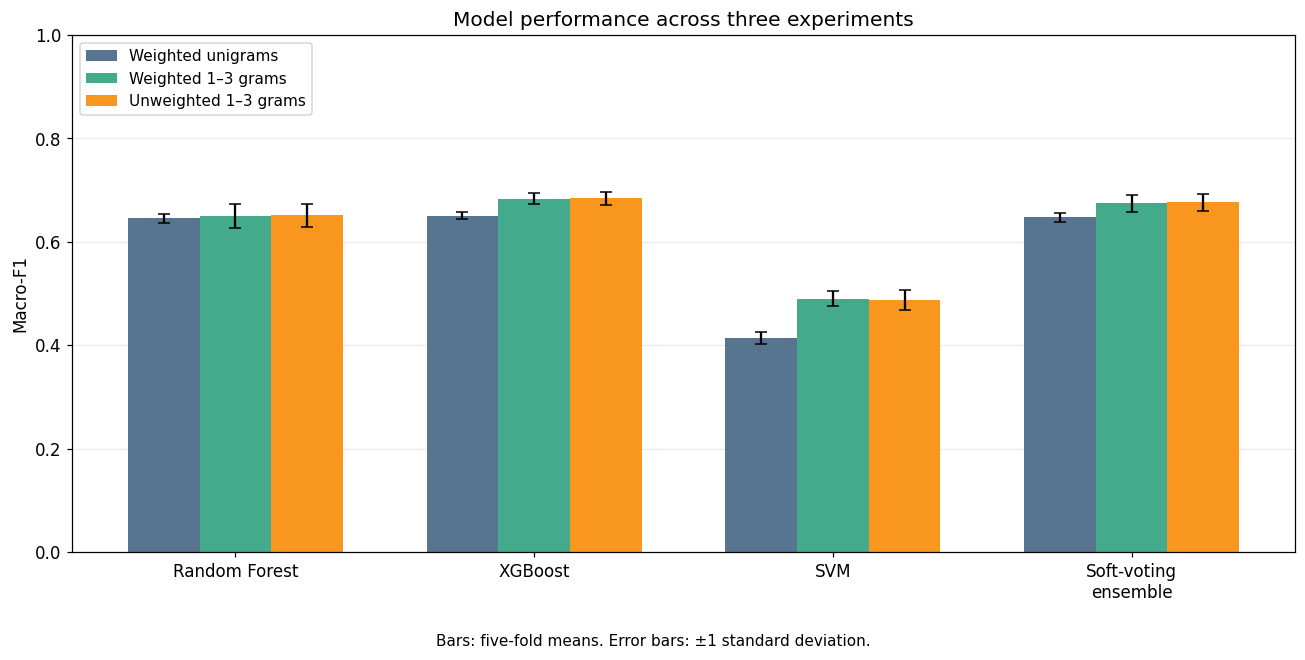

In [ ]:
means = (
    model_results
    .groupby(["Model", "Experiment"])["Macro F1"]
    .mean()
    .unstack()
    .reindex(index=model_order, columns=experiment_order)
)

stds = (
    model_results
    .groupby(["Model", "Experiment"])["Macro F1"]
    .std()
    .unstack()
    .reindex(index=model_order, columns=experiment_order)
)

positions = np.arange(len(model_order))
bar_width = 0.24
colors = ["#577590", "#43AA8B", "#F8961E"]

fig, ax = plt.subplots(figsize=(12, 6))

for index, experiment in enumerate(experiment_order):
    offset = (index - 1) * bar_width

    ax.bar(
        positions + offset,
        means[experiment],
        width=bar_width,
        yerr=stds[experiment],
        capsize=4,
        label=experiment,
        color=colors[index]
    )

ax.set_xticks(positions)
ax.set_xticklabels([
    "Random Forest",
    "XGBoost",
    "SVM",
    "Soft-voting\nensemble"
])

ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.set_title("Model performance across three experiments")
ax.legend(loc="upper left", fontsize=10)
ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

fig.text(
    0.5, 0.01,
    "Bars: five-fold means. Error bars: ±1 standard deviation.",
    ha="center",
    fontsize=10
)

fig.tight_layout(rect=[0, 0.05, 1, 1])

save_figure(fig, "macro_f1_comparison")
plt.show()
plt.close(fig)

,Model,Macro-F1 change from weighting
0,Random Forest,-0.0013
1,XGBoost,-0.0001
2,SVM,0.0036
3,Soft Voting Ensemble,-0.0017


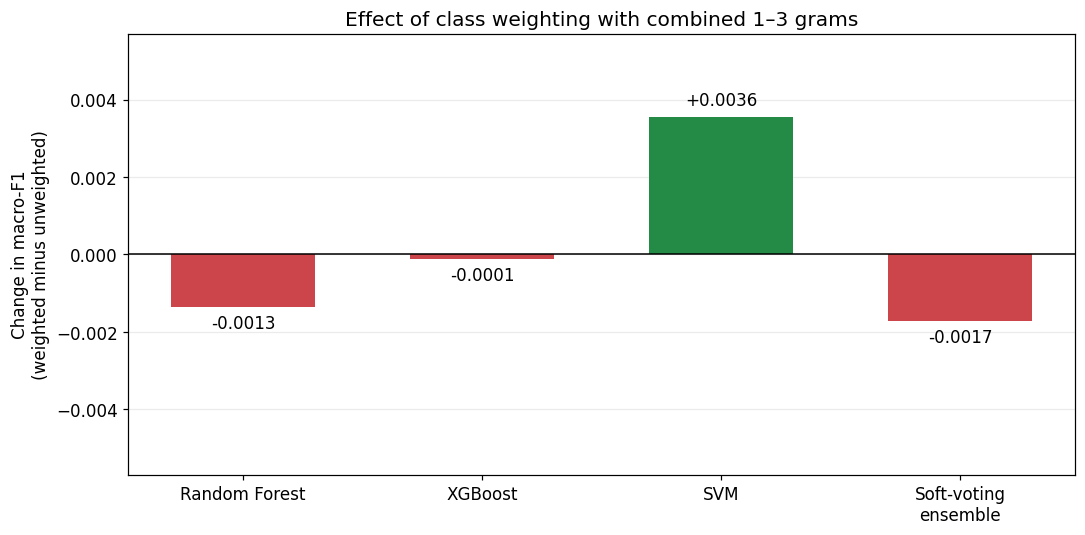

In [ ]:
weight_effect = (
    means["Weighted 1–3 grams"]
    - means["Unweighted 1–3 grams"]
)

effect_table = pd.DataFrame({
    "Model": model_order,
    "Macro-F1 change from weighting": weight_effect.to_numpy()
})

display(effect_table.round(4))

effect_table.to_csv(
    analysis_folder / "class_weighting_effect.csv",
    index=False
)

fig, ax = plt.subplots(figsize=(10, 5))

bar_colors = [
    "#238B45" if value >= 0 else "#CB454A"
    for value in weight_effect
]

bars = ax.bar(
    positions,
    weight_effect,
    color=bar_colors,
    width=0.6
)

ax.axhline(0, color="black", linewidth=1)

ax.set_xticks(positions)
ax.set_xticklabels([
    "Random Forest",
    "XGBoost",
    "SVM",
    "Soft-voting\nensemble"
])

ax.set_ylabel("Change in macro-F1\n(weighted minus unweighted)")
ax.set_title("Effect of class weighting with combined 1–3 grams")

# Symmetric scale around zero.
limit = max(abs(weight_effect).max() * 1.6, 0.005)
ax.set_ylim(-limit, limit)

for bar, value in zip(bars, weight_effect):
    ax.annotate(
        f"{value:+.4f}",
        xy=(bar.get_x() + bar.get_width() / 2, value),
        xytext=(0, 5 if value >= 0 else -5),
        textcoords="offset points",
        ha="center",
        va="bottom" if value >= 0 else "top"
    )

ax.grid(axis="y", alpha=0.25)
ax.set_axisbelow(True)

fig.tight_layout()

save_figure(fig, "class_weighting_effect")
plt.show()
plt.close(fig)

UNWEIGHTED XGBOOST — PER-CLASS FIVE-FOLD MEANS


,Precision,Recall,F1
Malware type,,,
Adware,0.9347,0.7490,0.8297
Backdoor,0.6872,0.6866,0.6863
Downloader,0.7618,0.7582,0.7594
Dropper,0.6015,0.6680,0.6327
Spyware,0.5607,0.5282,0.5424
Trojan,0.5105,0.5393,0.5227
Virus,0.8831,0.8369,0.8592
Worms,0.6273,0.6489,0.6371


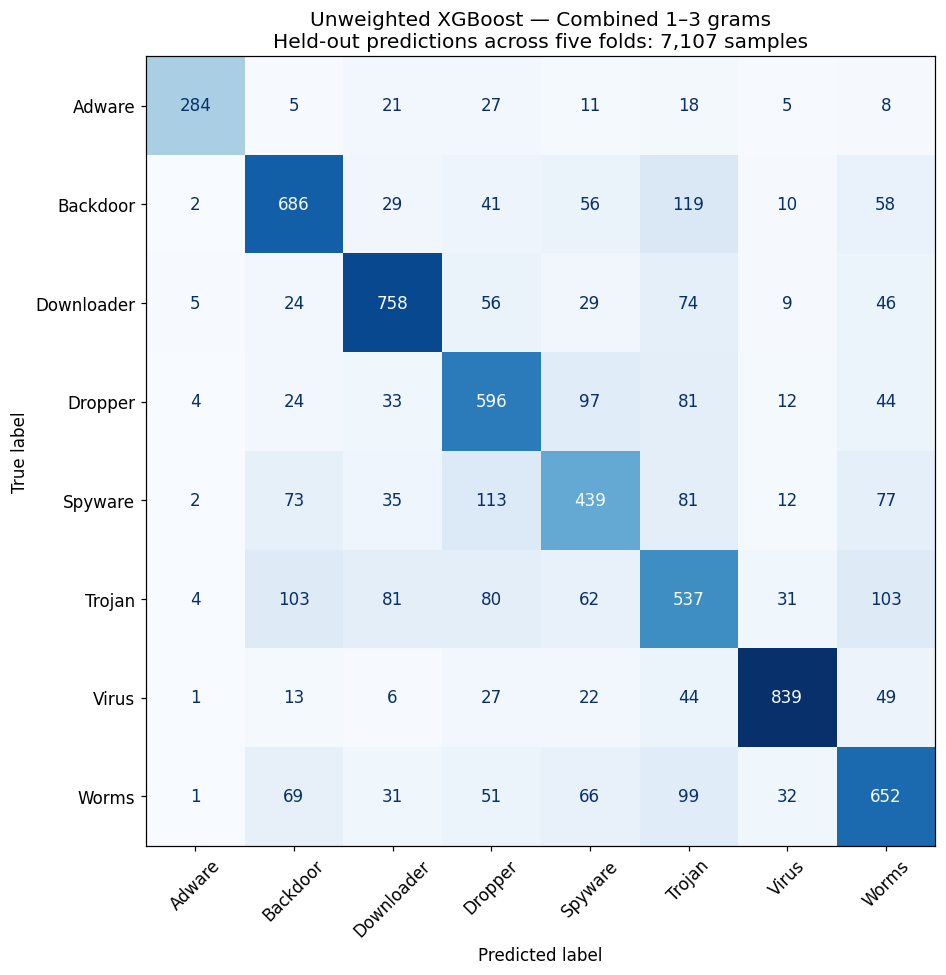

In [ ]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

prediction_parts = []
class_rows = []

manifest = pd.read_csv(
    results_folder / "fold_assignments.csv"
).set_index("sample_id")

class_names = sorted(manifest["label"].unique())

for fold_number in range(1, 6):

    prediction_path = (
        results_folder
        / "ngram13_unweighted"
        / f"fold_{fold_number}"
        / "predictions.csv"
    )

    predictions = pd.read_csv(prediction_path)

    expected = manifest.loc[predictions["sample_id"]]

    assert predictions["sample_id"].is_unique
    assert (expected["test_fold"] == fold_number).all()
    assert np.array_equal(
        predictions["true_label"].to_numpy(),
        expected["label"].to_numpy()
    )

    prediction_parts.append(predictions)

    report = classification_report(
        predictions["true_label"],
        predictions["XGBoost"],
        labels=class_names,
        output_dict=True,
        zero_division=0
    )

    for class_name in class_names:
        class_rows.append({
            "Fold": fold_number,
            "Malware type": class_name,
            "Precision": report[class_name]["precision"],
            "Recall": report[class_name]["recall"],
            "F1": report[class_name]["f1-score"]
        })

class_results = pd.DataFrame(class_rows)

class_summary = (
    class_results
    .groupby("Malware type")[["Precision", "Recall", "F1"]]
    .mean()
    .reindex(class_names)
)

print("UNWEIGHTED XGBOOST — PER-CLASS FIVE-FOLD MEANS")
display(class_summary.round(4))

class_summary.to_csv(
    analysis_folder / "xgboost_per_class_means.csv"
)

all_predictions = pd.concat(
    prediction_parts,
    ignore_index=True
)

assert len(all_predictions) == 7107
assert all_predictions["sample_id"].nunique() == 7107
assert set(all_predictions["sample_id"]) == set(manifest.index)

matrix = confusion_matrix(
    all_predictions["true_label"],
    all_predictions["XGBoost"],
    labels=class_names
)

pd.DataFrame(
    matrix,
    index=pd.Index(class_names, name="Actual"),
    columns=pd.Index(class_names, name="Predicted")
).to_csv(
    analysis_folder / "xgboost_confusion_matrix_counts.csv"
)

fig, ax = plt.subplots(figsize=(11, 9))

display_matrix = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=class_names
)

display_matrix.plot(
    ax=ax,
    cmap="Blues",
    values_format="d",
    xticks_rotation=45,
    colorbar=False
)

ax.set_title(
    "Unweighted XGBoost — Combined 1–3 grams\n"
    "Held-out predictions across five folds: 7,107 samples"
)

fig.tight_layout()

save_figure(fig, "xgboost_confusion_matrix")
plt.show()
plt.close(fig)

In [ ]:
import shutil
from google.colab import files

zip_path = shutil.make_archive(
    "/content/MalAPI_Tables_and_Figures",
    "zip",
    root_dir=str(analysis_folder)
)

print("Files created:")

for file_path in sorted(analysis_folder.iterdir()):
    if file_path.is_file():
        print(file_path.name)

files.download(zip_path)

Files created:
class_weighting_effect.csv
class_weighting_effect.pdf
class_weighting_effect.png
macro_f1_comparison.pdf
macro_f1_comparison.png
model_comparison_numeric.csv
model_comparison_table.csv
xgboost_confusion_matrix.pdf
xgboost_confusion_matrix.png
xgboost_confusion_matrix_counts.csv
xgboost_per_class_means.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## D. Ordinary versus grouped Random Forest comparison (original code cells 46–54)

Code and saved outputs below are preserved from the submitted experiment.


In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [2]:
from pathlib import Path

dataset_zip = Path(
    "/content/drive/MyDrive/"
    "mal-api-2019-20260919T173115Z-1-001.zip"
)

previous_results_folder = Path(
    "/content/drive/MyDrive/"
    "MalAPI_Corrected_Results/20260919_182045"
)

print("Dataset ZIP found:", dataset_zip.exists())
print("Previous results found:", previous_results_folder.exists())

if not dataset_zip.exists():
    raise FileNotFoundError(
        "Dataset ZIP পাওয়া যায়নি। এই output আমাকে পাঠাও।"
    )

if not previous_results_folder.exists():
    raise FileNotFoundError(
        "আগের results folder পাওয়া যায়নি। সঠিক Google account "
        "connect হয়েছে কি না দেখো।"
    )

print("\nPASS: dataset and previous results are available.")

Dataset ZIP found: True
Previous results found: True

PASS: dataset and previous results are available.


In [3]:
import shutil
import zipfile

local_folder = Path("/content/malapi_work")
local_folder.mkdir(parents=True, exist_ok=True)

local_zip = local_folder / "dataset.zip"

print("Copying dataset ZIP to Colab...", flush=True)

shutil.copy2(dataset_zip, local_zip)

if not zipfile.is_zipfile(local_zip):
    raise ValueError("The copied file is not a valid ZIP.")

with zipfile.ZipFile(local_zip) as archive:
    calls_files = [
        name
        for name in archive.namelist()
        if Path(name).name == "1000_calls.csv"
    ]

    labels_files = [
        name
        for name in archive.namelist()
        if Path(name).name == "labels.csv"
    ]

if len(calls_files) != 1:
    raise ValueError(
        f"Expected one 1000_calls.csv. Found: {calls_files}"
    )

if len(labels_files) != 1:
    raise ValueError(
        f"Expected one labels.csv. Found: {labels_files}"
    )

print("API sequence file:", calls_files[0])
print("Label file:", labels_files[0])
print("\nPASS: ZIP is ready.")

Copying dataset ZIP to Colab...
API sequence file: mal-api-2019/1000_calls.csv
Label file: mal-api-2019/mal-api-2019/labels.csv

PASS: ZIP is ready.


In [4]:
import csv
import io
import hashlib

import numpy as np
import pandas as pd

sequences = []
sequence_lengths = []
sequence_hashes = []

with zipfile.ZipFile(local_zip) as archive:

    with archive.open(labels_files[0]) as label_file:
        label_table = pd.read_csv(
            label_file,
            header=None,
            names=["label"],
            dtype=str,
            keep_default_na=False,
            skip_blank_lines=False
        )

    labels = label_table["label"].str.strip().tolist()

    if any(label == "" for label in labels):
        raise ValueError("An empty label was found.")

    with archive.open(calls_files[0]) as calls_file:
        text_file = io.TextIOWrapper(
            calls_file,
            encoding="utf-8-sig",
            newline=""
        )

        reader = csv.reader(text_file)

        for row_number, row in enumerate(reader, start=1):
            if not row:
                raise ValueError(
                    f"Empty sequence at row {row_number}"
                )

            calls = [value.strip() for value in row]

            if any(call == "" for call in calls):
                raise ValueError(
                    f"Empty API field at row {row_number}"
                )

            if not all(call.isdigit() for call in calls):
                raise ValueError(
                    f"Non-numeric API value at row {row_number}"
                )

            sequence = " ".join(calls)

            sequences.append(sequence)
            sequence_lengths.append(len(calls))
            sequence_hashes.append(
                hashlib.sha256(
                    sequence.encode("utf-8")
                ).hexdigest()
            )

            if row_number % 1000 == 0:
                print(
                    f"Loaded {row_number:,} sequences",
                    flush=True
                )

assert len(sequences) == len(labels), (
    "Sequence and label counts do not match."
)

assert len(sequences) == 7107, (
    f"Expected 7,107 samples, found {len(sequences)}."
)

data = pd.DataFrame({
    "sample_id": np.arange(len(sequences)),
    "api_sequence": sequences,
    "label": labels,
    "api_call_count": sequence_lengths,
    "sequence_group": sequence_hashes
})

expected_counts = {
    "Trojan": 1001,
    "Backdoor": 1001,
    "Downloader": 1001,
    "Worms": 1001,
    "Virus": 1001,
    "Dropper": 891,
    "Spyware": 832,
    "Adware": 379
}

assert data["label"].value_counts().to_dict() == expected_counts, (
    "Class counts do not match the verified dataset."
)

saved_data = pd.read_csv(
    previous_results_folder / "fold_assignments.csv"
)

assert len(saved_data) == len(data)
assert saved_data["sample_id"].is_unique
assert set(saved_data["sample_id"]) == set(data["sample_id"])

saved_data = (
    saved_data.set_index("sample_id")
    .loc[data["sample_id"]]
    .reset_index()
)

for column in [
    "sample_id",
    "label",
    "sequence_group",
    "api_call_count"
]:
    matches = np.array_equal(
        data[column].to_numpy(),
        saved_data[column].to_numpy()
    )

    print(f"{column} matches previous data: {matches}")
    assert matches, f"Mismatch in {column}"

print("\nDATA LOADED SUCCESSFULLY")
print("Samples:", len(data))
print("Classes:", data["label"].nunique())
print("Unique sequences:", data["sequence_group"].nunique())

display(
    data["label"]
    .value_counts()
    .rename_axis("Malware type")
    .reset_index(name="Samples")
)

print("\nPASS: data matches the previous experiment.")
print("No models have been trained.")
print("Previous result files have not been changed.")

Loaded 1,000 sequences
Loaded 2,000 sequences
Loaded 3,000 sequences
Loaded 4,000 sequences
Loaded 5,000 sequences
Loaded 6,000 sequences
Loaded 7,000 sequences
sample_id matches previous data: True
label matches previous data: True
sequence_group matches previous data: True
api_call_count matches previous data: True

DATA LOADED SUCCESSFULLY
Samples: 7107
Classes: 8
Unique sequences: 6518


,Malware type,Samples
0,Trojan,1001
1,Backdoor,1001
2,Downloader,1001
3,Worms,1001
4,Virus,1001
5,Dropper,891
6,Spyware,832
7,Adware,379



PASS: data matches the previous experiment.
No models have been trained.
Previous result files have not been changed.


In [5]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import hashlib
import json
import gc
from time import perf_counter

import numpy as np
import pandas as pd
import sklearn

from sklearn.model_selection import StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

previous_folder = Path(
    "/content/drive/MyDrive/"
    "MalAPI_Corrected_Results/20260919_182045"
)

if "data" not in globals():
    raise RuntimeError(
        "Data is not loaded. Run the first four original code cells, "
        "ending with DATA LOADED SUCCESSFULLY, then run this cell again."
    )

comparison_data = data.reset_index(drop=True).copy()

saved_manifest = pd.read_csv(
    previous_folder / "fold_assignments.csv"
)

previous_scores = pd.read_csv(
    previous_folder / "five_fold_all_results.csv"
)

with open(previous_folder / "experiment_settings.json") as file:
    previous_settings = json.load(file)

assert len(comparison_data) == 7107
assert comparison_data["sample_id"].is_unique
assert saved_manifest["sample_id"].is_unique

saved_manifest = (
    saved_manifest.set_index("sample_id")
    .loc[comparison_data["sample_id"]]
    .reset_index()
)

for column in [
    "sample_id", "label", "sequence_group", "api_call_count"
]:
    assert np.array_equal(
        comparison_data[column].to_numpy(),
        saved_manifest[column].to_numpy()
    ), f"Dataset mismatch: {column}"

current_hashes = comparison_data["api_sequence"].map(
    lambda sequence: hashlib.sha256(
        sequence.encode("utf-8")
    ).hexdigest()
)

assert np.array_equal(
    current_hashes.to_numpy(),
    saved_manifest["sequence_group"].to_numpy()
), "The actual API sequences do not match the saved experiment."

assert set(saved_manifest["test_fold"]) == {1, 2, 3, 4, 5}

old_version = previous_settings.get("sklearn_version")

print("Previous sklearn version:", old_version)
print("Current sklearn version:", sklearn.__version__)

if old_version != sklearn.__version__:
    raise RuntimeError(
        "The sklearn versions differ. Share this output before training "
        "so we can match the previous environment."
    )

grouped_rf = previous_scores.loc[
    previous_scores["Model"] == "Random Forest"
].copy()

assert len(grouped_rf) == 5
assert set(grouped_rf["Fold"]) == {1, 2, 3, 4, 5}

comparison_classes = sorted(comparison_data["label"].unique())

print("\nPREVIOUS GROUPED RANDOM FOREST")
display(
    grouped_rf[
        ["Fold", "Accuracy", "Macro Precision", "Macro Recall", "Macro F1"]
    ].round(4)
)

print("\nPASS: data and saved results match.")
print("No models have been retrained.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Previous sklearn version: 1.6.1
Current sklearn version: 1.6.1

PREVIOUS GROUPED RANDOM FOREST


,Fold,Accuracy,Macro Precision,Macro Recall,Macro F1
1,1,0.6568,0.6658,0.6515,0.6556
6,2,0.6759,0.7032,0.6773,0.6850
11,3,0.6187,0.6387,0.6371,0.6340
16,4,0.6347,0.6594,0.6449,0.6494
21,5,0.6124,0.6341,0.6209,0.6249



PASS: data and saved results match.
No models have been retrained.


In [6]:
comparison_folder = previous_folder / "ordinary_vs_grouped_rf"
comparison_folder.mkdir(parents=True, exist_ok=True)

ordinary_splitter = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

ordinary_folds = list(
    ordinary_splitter.split(
        comparison_data["api_sequence"],
        comparison_data["label"]
    )
)

ordinary_assignment = np.full(len(comparison_data), -1, dtype=int)
overlap_rows = []
distribution_rows = []

grouped_assignment = saved_manifest["test_fold"].to_numpy()

def record_split(method, fold_number, train_ids, test_ids):
    train_part = comparison_data.iloc[train_ids]
    test_part = comparison_data.iloc[test_ids]

    train_groups = set(train_part["sequence_group"])
    test_groups = set(test_part["sequence_group"])

    shared_groups = train_groups.intersection(test_groups)
    exposed_test = test_part["sequence_group"].isin(train_groups)

    assert set(train_part["label"]) == set(comparison_classes)
    assert set(test_part["label"]) == set(comparison_classes)

    overlap_rows.append({
        "Split": method,
        "Fold": fold_number,
        "Training samples": len(train_ids),
        "Test samples": len(test_ids),
        "Shared sequence groups": len(shared_groups),
        "Test samples with sequence in training": int(exposed_test.sum()),
        "Overlap test percentage": 100 * exposed_test.mean()
    })

    for partition, part in [
        ("Train", train_part), ("Test", test_part)
    ]:
        counts = part["label"].value_counts()
        for category in comparison_classes:
            distribution_rows.append({
                "Split": method,
                "Fold": fold_number,
                "Partition": partition,
                "Class": category,
                "Samples": int(counts.get(category, 0))
            })

    if method == "Grouped":
        assert len(shared_groups) == 0

for fold_number, (train_ids, test_ids) in enumerate(
    ordinary_folds, start=1
):
    assert np.all(ordinary_assignment[test_ids] == -1)
    ordinary_assignment[test_ids] = fold_number

    record_split("Ordinary", fold_number, train_ids, test_ids)

    grouped_test = np.flatnonzero(grouped_assignment == fold_number)
    grouped_train = np.flatnonzero(grouped_assignment != fold_number)

    record_split("Grouped", fold_number, grouped_train, grouped_test)

assert np.all(ordinary_assignment > 0)

ordinary_manifest = saved_manifest.copy()
ordinary_manifest["test_fold"] = ordinary_assignment

fingerprint = hashlib.sha256(
    ordinary_manifest.to_csv(index=False).encode("utf-8")
).hexdigest()

comparison_settings = {
    "experiment": "Ordinary versus grouped RF",
    "sklearn_version": sklearn.__version__,
    "dataset_and_ordinary_folds_sha256": fingerprint,
    "split": "StratifiedKFold",
    "n_splits": 5,
    "seed": 42,
    "tfidf": {
        "tokenizer": "str.split",
        "lowercase": False,
        "ngram_range": [1, 3],
        "min_df": 2,
        "max_features": 50000,
        "dtype": "float32"
    },
    "random_forest": {
        "n_estimators": 300,
        "class_weight": "balanced",
        "random_state": 42,
        "n_jobs": -1
    }
}

settings_path = comparison_folder / "settings.json"

if settings_path.exists():
    with open(settings_path) as file:
        assert json.load(file) == comparison_settings, (
            "Saved comparison settings differ. Stop before reusing results."
        )
else:
    with open(settings_path, "w") as file:
        json.dump(comparison_settings, file, indent=2)

ordinary_manifest.to_csv(
    comparison_folder / "ordinary_fold_assignments.csv",
    index=False
)

overlap_table = pd.DataFrame(overlap_rows)

overlap_table.to_csv(
    comparison_folder / "split_overlap_audit.csv",
    index=False
)

pd.DataFrame(distribution_rows).to_csv(
    comparison_folder / "class_distribution_by_fold.csv",
    index=False
)

display(
    overlap_table.sort_values(["Split", "Fold"]).round(2)
)

print("\nPASS: folds and overlap audit saved.")
print("Training has not started yet.")
print("Output folder:", comparison_folder)

,Split,Fold,Training samples,Test samples,Shared sequence groups,Test samples with sequence in training,Overlap test percentage
1,Grouped,1,5688,1419,0,0,0.00
3,Grouped,2,5660,1447,0,0,0.00
5,Grouped,3,5709,1398,0,0,0.00
7,Grouped,4,5678,1429,0,0,0.00
9,Grouped,5,5693,1414,0,0,0.00
0,Ordinary,1,5685,1422,122,165,11.60
2,Ordinary,2,5685,1422,113,159,11.18
4,Ordinary,3,5686,1421,111,145,10.20
6,Ordinary,4,5686,1421,110,158,11.12
8,Ordinary,5,5686,1421,128,161,11.33



PASS: folds and overlap audit saved.
Training has not started yet.
Output folder: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045/ordinary_vs_grouped_rf


In [7]:
def comparison_metrics(actual, predicted):
    return {
        "Accuracy": accuracy_score(actual, predicted),
        "Macro Precision": precision_score(
            actual, predicted,
            labels=comparison_classes,
            average="macro",
            zero_division=0
        ),
        "Macro Recall": recall_score(
            actual, predicted,
            labels=comparison_classes,
            average="macro",
            zero_division=0
        ),
        "Macro F1": f1_score(
            actual, predicted,
            labels=comparison_classes,
            average="macro",
            zero_division=0
        )
    }

ordinary_rows = []

for fold_number, (train_ids, test_ids) in enumerate(
    ordinary_folds, start=1
):
    print(f"\nORDINARY FOLD {fold_number}/5", flush=True)

    train_part = comparison_data.iloc[train_ids]
    test_part = comparison_data.iloc[test_ids]

    prediction_path = (
        comparison_folder / f"fold_{fold_number}_predictions.csv"
    )

    if prediction_path.exists():
        prediction_table = pd.read_csv(prediction_path)

        assert np.array_equal(
            prediction_table["sample_id"].to_numpy(),
            test_part["sample_id"].to_numpy()
        )
        assert np.array_equal(
            prediction_table["true_label"].to_numpy(),
            test_part["label"].to_numpy()
        )
        assert set(prediction_table["rf_prediction"]).issubset(
            set(comparison_classes)
        )

        predictions = prediction_table["rf_prediction"].to_numpy()

        print("Reused saved predictions. No retraining.", flush=True)

    else:
        print("Preparing training-only TF-IDF...", flush=True)
        started = perf_counter()

        ordinary_vectorizer = TfidfVectorizer(
            tokenizer=str.split,
            token_pattern=None,
            lowercase=False,
            ngram_range=(1, 3),
            min_df=2,
            max_features=50000,
            dtype=np.float32
        )

        train_matrix = ordinary_vectorizer.fit_transform(
            train_part["api_sequence"]
        )
        test_matrix = ordinary_vectorizer.transform(
            test_part["api_sequence"]
        )

        feature_seconds = perf_counter() - started

        print("Training matrix:", train_matrix.shape, flush=True)
        print("Training Random Forest...", flush=True)

        ordinary_model = RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        )

        started = perf_counter()
        ordinary_model.fit(train_matrix, train_part["label"])
        training_seconds = perf_counter() - started

        started = perf_counter()
        predictions = ordinary_model.predict(test_matrix)
        prediction_seconds = perf_counter() - started

        timing = {
            "Fold": fold_number,
            "Feature count": int(train_matrix.shape[1]),
            "Feature seconds": feature_seconds,
            "Training seconds": training_seconds,
            "Prediction seconds": prediction_seconds
        }

        pd.DataFrame([timing]).to_csv(
            comparison_folder / f"fold_{fold_number}_timing.csv",
            index=False
        )

        prediction_table = pd.DataFrame({
            "sample_id": test_part["sample_id"].to_numpy(),
            "true_label": test_part["label"].to_numpy(),
            "rf_prediction": predictions,
            "sequence_seen_in_training": (
                test_part["sequence_group"]
                .isin(set(train_part["sequence_group"]))
                .to_numpy()
            )
        })

        temporary_path = prediction_path.with_suffix(".tmp")
        prediction_table.to_csv(temporary_path, index=False)
        temporary_path.replace(prediction_path)

        del ordinary_model, ordinary_vectorizer
        del train_matrix, test_matrix
        gc.collect()

        print(
            f"Saved. Feature preparation: {feature_seconds / 60:.1f} min; "
            f"training: {training_seconds / 60:.1f} min.",
            flush=True
        )

    row = {
        "Split": "Ordinary",
        "Fold": fold_number,
        "Model": "Random Forest",
        **comparison_metrics(
            test_part["label"].to_numpy(),
            predictions
        )
    }

    ordinary_rows.append(row)

    pd.DataFrame(ordinary_rows).to_csv(
        comparison_folder / "ordinary_five_fold_results.csv",
        index=False
    )

    display(pd.DataFrame([row]).round(4))

print("\nALL FIVE ORDINARY FOLDS ARE COMPLETE.")
print("Results saved to:", comparison_folder)


ORDINARY FOLD 1/5
Preparing training-only TF-IDF...
Training matrix: (5685, 39094)
Training Random Forest...
Saved. Feature preparation: 3.8 min; training: 1.8 min.


,Split,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Ordinary,1,Random Forest,0.6793,0.7011,0.6843,0.6895



ORDINARY FOLD 2/5
Preparing training-only TF-IDF...
Training matrix: (5685, 38887)
Training Random Forest...
Saved. Feature preparation: 3.5 min; training: 2.1 min.


,Split,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Ordinary,2,Random Forest,0.6547,0.6785,0.6606,0.666



ORDINARY FOLD 3/5
Preparing training-only TF-IDF...
Training matrix: (5686, 38998)
Training Random Forest...
Saved. Feature preparation: 3.5 min; training: 2.4 min.


...


ORDINARY FOLD 4/5
Preparing training-only TF-IDF...
Training matrix: (5686, 38796)
Training Random Forest...
Saved. Feature preparation: 3.6 min; training: 2.2 min.


,Split,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Ordinary,4,Random Forest,0.6538,0.6717,0.6696,0.6691



ORDINARY FOLD 5/5
Preparing training-only TF-IDF...
Training matrix: (5686, 38877)
Training Random Forest...
Saved. Feature preparation: 3.4 min; training: 2.1 min.


,Split,Fold,Model,Accuracy,Macro Precision,Macro Recall,Macro F1
0,Ordinary,5,Random Forest,0.665,0.6821,0.6704,0.674



ALL FIVE ORDINARY FOLDS ARE COMPLETE.
Results saved to: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045/ordinary_vs_grouped_rf


RANDOM FOREST — WEIGHTED COMBINED 1–3 GRAMS
FIVE-FOLD MEAN AND STANDARD DEVIATION


Accuracy         Macro Precision         Macro Recall          \
             mean     std            mean     std         mean     std   
Split                                                                    
Grouped    0.6397  0.0265          0.6602  0.0275       0.6463  0.0207   
Ordinary   0.6623  0.0105          0.6823  0.0111       0.6705  0.0087   

         Macro F1          
             mean     std  
Split                      
Grouped    0.6498  0.0231  
Ordinary   0.6738  0.0093


DIFFERENCE BETWEEN MEAN SCORES


,Metric,Ordinary minus grouped (percentage points)
0,Accuracy,2.259
1,Macro Precision,2.205
2,Macro Recall,2.413
3,Macro F1,2.405


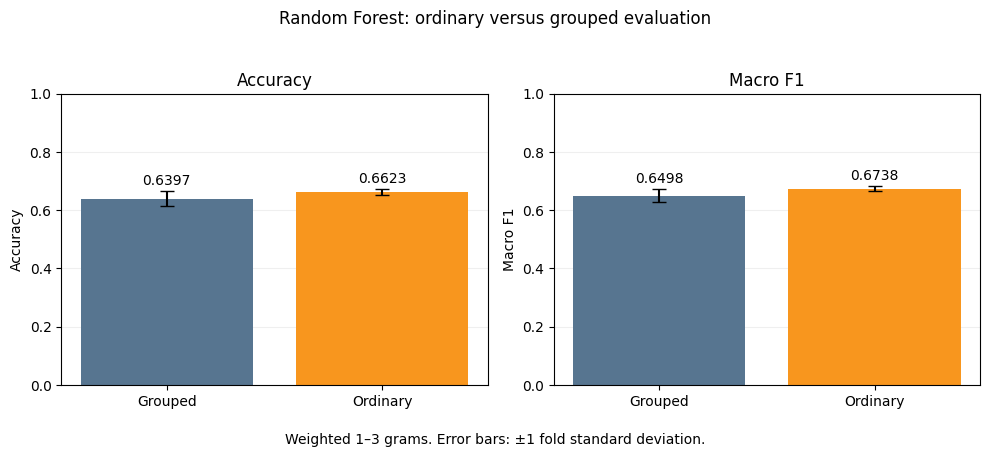


Saved tables and graphs to: /content/drive/MyDrive/MalAPI_Corrected_Results/20260919_182045/ordinary_vs_grouped_rf
Interpretation: this compares evaluation protocols. The test partitions also differ, so the score difference is not a perfectly isolated causal effect of duplicate overlap.


In [8]:
import matplotlib.pyplot as plt

metric_names = [
    "Accuracy", "Macro Precision", "Macro Recall", "Macro F1"
]

ordinary_results = pd.read_csv(
    comparison_folder / "ordinary_five_fold_results.csv"
)

assert len(ordinary_results) == 5
assert set(ordinary_results["Fold"]) == {1, 2, 3, 4, 5}

grouped_results = grouped_rf.copy()
grouped_results["Split"] = "Grouped"

combined_results = pd.concat(
    [
        grouped_results[["Split", "Fold", "Model"] + metric_names],
        ordinary_results[["Split", "Fold", "Model"] + metric_names]
    ],
    ignore_index=True
)

split_summary = (
    combined_results.groupby("Split")[metric_names]
    .agg(["mean", "std"])
    .reindex(["Grouped", "Ordinary"])
)

combined_results.to_csv(
    comparison_folder / "both_split_results.csv",
    index=False
)

split_summary.to_csv(
    comparison_folder / "split_comparison_summary.csv"
)

print("RANDOM FOREST — WEIGHTED COMBINED 1–3 GRAMS")
print("FIVE-FOLD MEAN AND STANDARD DEVIATION")
display(split_summary.round(4))

differences = pd.DataFrame({
    "Metric": metric_names,
    "Ordinary minus grouped (percentage points)": [
        100 * (
            split_summary.loc["Ordinary", (metric, "mean")]
            - split_summary.loc["Grouped", (metric, "mean")]
        )
        for metric in metric_names
    ]
})

print("\nDIFFERENCE BETWEEN MEAN SCORES")
display(differences.round(3))

differences.to_csv(
    comparison_folder / "mean_score_differences.csv",
    index=False
)

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

for axis, metric in zip(axes, ["Accuracy", "Macro F1"]):
    values = split_summary[(metric, "mean")].to_numpy()
    errors = split_summary[(metric, "std")].to_numpy()

    bars = axis.bar(
        ["Grouped", "Ordinary"],
        values,
        yerr=errors,
        capsize=5,
        color=["#577590", "#F8961E"]
    )

    axis.set_ylim(0, 1)
    axis.set_ylabel(metric)
    axis.set_title(metric)
    axis.grid(axis="y", alpha=0.2)
    axis.set_axisbelow(True)

    for bar, value, error in zip(bars, values, errors):
        axis.text(
            bar.get_x() + bar.get_width() / 2,
            value + error + 0.02,
            f"{value:.4f}",
            ha="center"
        )

fig.suptitle("Random Forest: ordinary versus grouped evaluation")
fig.text(
    0.5, 0.015,
    "Weighted 1–3 grams. Error bars: ±1 fold standard deviation.",
    ha="center",
    fontsize=10
)

fig.tight_layout(rect=[0, 0.06, 1, 0.95])

for extension in ["png", "pdf"]:
    fig.savefig(
        comparison_folder / f"split_comparison.{extension}",
        dpi=300,
        bbox_inches="tight"
    )

plt.show()
plt.close(fig)

print("\nSaved tables and graphs to:", comparison_folder)
print(
    "Interpretation: this compares evaluation protocols. "
    "The test partitions also differ, so the score difference "
    "is not a perfectly isolated causal effect of duplicate overlap."
)

In [9]:
from pathlib import Path
from datetime import datetime
import shutil
from google.colab import files

source_folder = Path(
    "/content/drive/MyDrive/"
    "MalAPI_Corrected_Results/20260919_182045/"
    "ordinary_vs_grouped_rf"
)

if not source_folder.exists():
    raise FileNotFoundError(
        "Results folder পাওয়া যায়নি। Google Drive connect আছে কি না দেখো।"
    )

required_files = [
    "settings.json",
    "ordinary_fold_assignments.csv",
    "split_overlap_audit.csv",
    "ordinary_five_fold_results.csv",
    "split_comparison_summary.csv",
    "mean_score_differences.csv",
    "split_comparison.png",
    "split_comparison.pdf"
]

for filename in required_files:
    if not (source_folder / filename).exists():
        raise FileNotFoundError(f"Missing file: {filename}")

backup_name = (
    "MalAPI_Split_Comparison_"
    + datetime.now().strftime("%Y%m%d_%H%M%S")
)

print("Creating ZIP...", flush=True)

zip_path = Path(
    shutil.make_archive(
        f"/content/{backup_name}",
        "zip",
        root_dir=str(source_folder.parent),
        base_dir=source_folder.name
    )
)

backup_folder = Path(
    "/content/drive/MyDrive/MalAPI_Backups"
)
backup_folder.mkdir(parents=True, exist_ok=True)

drive_backup = backup_folder / zip_path.name
shutil.copy2(zip_path, drive_backup)

assert drive_backup.stat().st_size == zip_path.stat().st_size

print("\nBACKUP SAVED TO GOOGLE DRIVE:")
print(drive_backup)

print(
    "\nZIP size:",
    round(zip_path.stat().st_size / (1024 * 1024), 2),
    "MB"
)

print("\nStarting laptop download...")
files.download(str(zip_path))

Creating ZIP...

BACKUP SAVED TO GOOGLE DRIVE:
/content/drive/MyDrive/MalAPI_Backups/MalAPI_Split_Comparison_20260921_123136.zip

ZIP size: 0.43 MB

Starting laptop download...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>